<a href="https://colab.research.google.com/github/oluaptom-dev/DBN/blob/main/DSTNM_300426.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Differential Binary Noise Modulation

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import integrate, stats, special
from scipy.special import erfc

# **Basar e Unb**
1 Communication_by_Means_of_Thermal_Noise_Toward_Networks_With_Extremely_Low_Power_Consumption

1- 1  Noise_Modulation Basar

2 OnOff_Digital_Noise_Modulation 2025

3 Differential_Noise_Modulation 2026 analise


# **Refe**
1 A_Survey_on_Noise-Based_Communication 2017

2 Differential_space-time_modulation 2000

3 A_Comprehensive_Survey_on_Ambient_Backscatter_Communications_Toward_Zero-Energy_Devices_and_Networks

4 Ternary Noise Modulation WCL2026 Basar

# **Resumo das funções: 3 Differential da unb em analise  - 2026**
## Caso AWGN
simulate_dbn()         = monte carlos

Q()

dbn_gauss_approx()     = aprox para AWGN apenas

dbn_teorica_dbn()      = teorica para AWGN

## Sem linha de visada (ambiente laboratorio)
Caso non-line-of-sight  - NLos  (sem visada direta)

bep_teorica_dbn_nlos() = teorica para nLos

# **1 AWGN**

In [ ]:


# função base do DBN

def simulate_dbn(N, snr_db, n_bits, L=100):
  #numero de frame será fixo L= 100 (ou seja a cada 100 simbolos muda vetor u)
  #cada simbolo tem uma repetição do sinal de N - ganho
  # E_u​=  ∥u∥^2  ∼  Gamma  --> está no artigo!

    # --- SNR linear ---
    gamma = 10**(snr_db / 10)

    # --- variâncias ---
    sigma_u = 1.0
    sigma_w = sigma_u / np.sqrt(gamma) # Pq raiz(gamma)? aqui é desvio padrao. Logo ao isolar surge a raiz.

    # ==========================
    # Ajuste: múltiplo de L
    # ==========================
    n_bits = (n_bits // L) * L  # garante blocos completos

    errors = 0
    total_bits = 0

    # ==========================
    # Loop por frames
    # ==========================
    for i in range(0, n_bits, L):   # inicia em 0 até <= n_bits de L em L.

        # ==========================
        # 1. Bits do frame
        # ==========================
        bits = np.random.randint(0, 2, L)   # 0 (minimo inclusivo) ; 2(maximo exclusivo); L qtd elementos = 0 ou 1

        # ==========================
        # 2. Codificação diferencial
        # ==========================
        s = np.ones(L + 1)                #indiretamento já faz s_0 = 1  (padrao/referencia) VEJA QUE AGORA TEM 1 SIMBOLO A MAIS = L+1
        s[1:] = np.cumprod(1 - 2 * bits)  # codifica a partir do segundo elemento (agora tera s = +1 ou -1)

        # ==========================
        # 3. NOVO u por frame (ESSENCIAL)    #raiz(2) normaliza (real+imag) para que E[||u||^2] = sigma_u^2 = ∑∣un​∣2
        # ==========================         # gera "u" uma vez por frame
        u = (np.random.normal(0, sigma_u/np.sqrt(2), N) +
             1j * np.random.normal(0, sigma_u/np.sqrt(2), N))

        # ==========================
        # 4. Transmissão
        # ==========================# X = s[:, None] * u[None, :]  (equivalente)
        X = np.outer(s, u)          # produto externo entre dois vetores
                                    # cada linha → um símbolo s_k   (p/ u tem parte real e imaginaria)

        # ==========================
        # 5. Canal AWGN
        # ==========================
        W = (np.random.normal(0, sigma_w/np.sqrt(2), (L + 1, N)) +
             1j * np.random.normal(0, sigma_w/np.sqrt(2), (L + 1, N)))

        Y = X + W

        # ==========================
        # 6. Detector diferencial
        # ==========================
        Z = np.sum(Y[1:] * np.conj(Y[:-1]), axis=1)      # y_(k,n)  x y_(k-1,n)^*
                                                         # axis=1 --> soma sobre as colunas: (n=1 até N)
                                                         # conj deveria estar no primeiro termo, ????????? é o certo, mas parece nao interferir

        bits_hat = (np.real(Z) < 0).astype(int)         # Isso gera um vetor booleano: true=negativo e depois converte para bit --> true=1

        # ==========================
        # 7. Contagem de erros
        # ==========================
        errors += np.sum(bits != bits_hat)
        # assert len(bits_hat) == len(bits) é um verificador (se for falso para o programa e apresenta um erro)

        total_bits += L

    # ==========================
    # BER final
    # ==========================
    ber = errors / total_bits

    return ber

# ==============================
# 3. Função Q (estável numericamente)
# ==============================
def Q(x):
    # Implementação da função Q usando a função de erro complementar
    return 0.5 * erfc(x / np.sqrt(2))

# ==============================
# 4. BER teórica (aproximação CLT)
# ==============================
def simpl_gauss_approx(N, snr_db):  # Eq 14 do artigo "Differential Binary Noise Modulation"

    gamma = 10**(snr_db / 10)

    num = np.sqrt(N) * gamma
    den = np.sqrt(gamma**2 + gamma + 0.5)

    return Q(num / den)




In [ ]:
from scipy import stats, integrate
from scipy.special import erfc
import numpy as np


def dbn_teorica_dbn(N, snr_db):    # Teorica sem a aproximação gaussiana ou seja aqui é a EQ 13 do artigo.

    # ==========================
    # Parâmetros consistentes com simulação
    # ==========================
    gamma_bar = 10**(snr_db / 10)

    sigma_u2 = 1.0
    sigma_w2 = 1.0 / gamma_bar

    # ==========================
    # Integrando Eq. (13)
    # ==========================
    def integrand(e):
        """
        e: representa a variável de integração Eu (energia da realização de ruído)
        """

        num = e
        den = np.sqrt(sigma_w2 * e + (N / 2) * (sigma_w2**2))  # Eq 11 do artigo

        # Probabilidade de erro condicional Pe(Eu)
        pe_cond = Q(num / den)

        # fEu(e): PDF Gamma da energia Eu com forma N e escala sigma_u^2
        pdf_e = stats.gamma.pdf(e, a=N, scale=sigma_u2)

        return pe_cond * pdf_e

    # Integração numérica de 0 a infinito
    # O resultado é a BEP incondicional (P_DBN_e)

    # ==========================
    # Limite superior numérico para evitar o infinito e possivel erro de integ.
    # ==========================
    e_max = stats.gamma.ppf(0.999999, a=N, scale=sigma_u2)

    # ==========================
    # Integração
    # ==========================
    #      bep, _ = integrate.quad(integrand, 0, e_max, limit=200) # com limite da erro!!!!
    bep, _ = integrate.quad(integrand, 0, np.inf)  # sugestão sem e_max para pegar a cauda completa.

    return bep

In [ ]:
# ==============================
# 1. Parâmetros do sistema
# ==============================
N = 20                     # Amostras por símbolo (Processing Gain)
snr_db_range = np.arange(-10, 11, 1) # Range de -10 a +10 dB com passo de 1 dB (21 pontos)
num_bits = 1000000           # Número de bits (Monte Carlo) 100mil é razoavel
# Sugestão de 5-10milhoes para erros na casa de 10^-5, contudo 1milhao já demora muito.

# ==============================
# 2. Função principal DBN
# ==============================

# ber_sim = [simulate_dbn(N, snr, num_bits) for snr in snr_db_range]
# ????? ISSO É USADO AQUI . POR QUE ABAIXO USA DE NOVO . aCHO QUE NAO  É USADO ESSA

In [ ]:
# ==============================
# 5. Simulação Monte Carlo e TEORICOS
# ==============================
ber_sim = []
ber_appr = []
ber_theo = []
for snr in snr_db_range:
    print(f"Simulando SNR = {snr} dB...")

    ber_sim.append(simulate_dbn(N, snr, num_bits))  # monte carlo
    ber_appr.append(simpl_gauss_approx(N, snr))     # aprox gaussiana
    ber_theo.append(dbn_teorica_dbn(N, snr))     # teorica com quadratura

Simulando SNR = -10 dB...
Simulando SNR = -9 dB...
Simulando SNR = -8 dB...
Simulando SNR = -7 dB...
Simulando SNR = -6 dB...
Simulando SNR = -5 dB...
Simulando SNR = -4 dB...
Simulando SNR = -3 dB...
Simulando SNR = -2 dB...
Simulando SNR = -1 dB...
Simulando SNR = 0 dB...
Simulando SNR = 1 dB...
Simulando SNR = 2 dB...
Simulando SNR = 3 dB...
Simulando SNR = 4 dB...
Simulando SNR = 5 dB...
Simulando SNR = 6 dB...
Simulando SNR = 7 dB...
Simulando SNR = 8 dB...
Simulando SNR = 9 dB...
Simulando SNR = 10 dB...


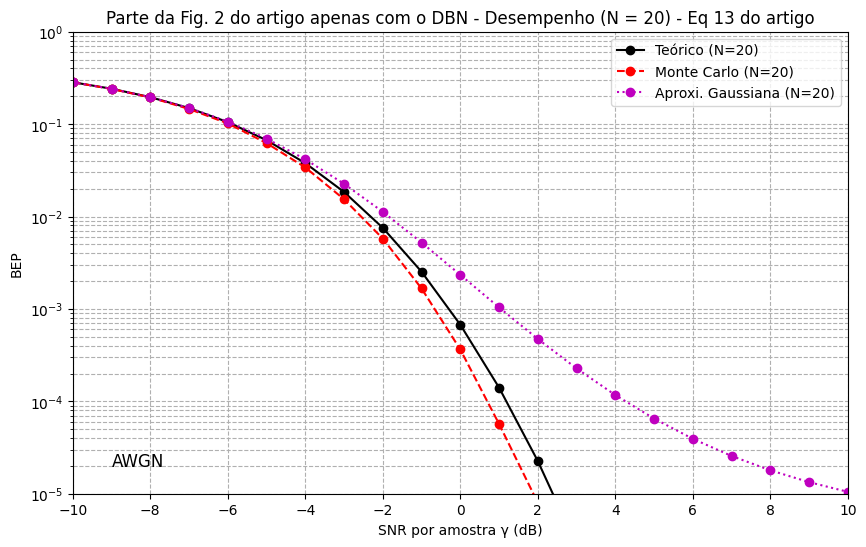

In [ ]:
# ==============================
# 6. Plot
# ==============================
plt.figure(figsize=(10, 6))

plt.semilogy(snr_db_range, ber_theo, 'ko-', label=f'Teórico (N={N})')  # 'cor + marcador + linha (opcional)'
plt.semilogy(snr_db_range, ber_sim, 'ro--', label=f'Monte Carlo (N={N})')
plt.semilogy(snr_db_range, ber_appr, 'mo:', label=f'Aproxi. Gaussiana (N={N})')

#  os^x+*d = circulo/quadrado/triangulo/X/mais/estrela/losango
#  bgrcmyk = azul/verde/vermelho/ciano/magenta/amarelo/preto
#  -/--/-./:   = continua/tracejada/traço-ponto/pontilhada

plt.grid(True, which='both', linestyle='--')
plt.xlabel('SNR por amostra γ (dB)')
plt.ylabel('BEP')
plt.title(f'Parte da Fig. 2 do artigo apenas com o DBN - Desempenho (N = {N}) - Eq 13 do artigo')
plt.legend()
plt.ylim(1e-5, 1) # Define o limite inferior do eixo Y para 10^-5 e o superior para 1
plt.xlim(-10, 10) # Define o limite inferior do eixo X para -10 e +10
plt.xticks(np.arange(-10, 11, 2)) # Define os ticks do eixo X de -10 a +10 com

plt.text(0.05, 0.05, 'AWGN', transform=plt.gca().transAxes,
         fontsize=12, verticalalignment='bottom', horizontalalignment='left')
# BEP seria para curvas analiticas (normalmente indica curvas continuas.)
# BER seria para monte carlos      (ou diz que é uma SIMULAÇAO BEP)

plt.show()

# **Aproximação Gaussiana para AWGN**
Eq. 14 foi usada como uma alternativa simplificada (e menos precisa para N pequeno) para facilitar o entendimento do ganho de processamento  $\sqrt{N}$.
O autor observa que, para N=20, essa aproximação simplificada é aceitável apenas no regime de **SNR baixo** (abaixo de -2 dB), começando a divergir da realidade teórica em SNRs mais altos.

Para N=100, ela se torna um preditor muito mais fiel.

# **Eficiência Espectral (η):**
Na modulação por ruído (DBN, NoiseMod ou OODN), cada bit de informação é representado por um bloco de N amostras complexas.

Como cada bit ocupa N amostras e a largura de banda mínima (B) é aproximadamente igual à frequência de amostragem ($fs$) em banda base complexa, temos: $$η=\frac{1}{N}  \quad \text{bits/s/Hz}$$

# **Frequência de Amostragem ($f_s$):**
É o número de amostras processadas por segundo. Ela é definida pelo hardware (SDR) ou pela banda disponível. A relação com a taxa de bits é: $$f_s = N * R_b \quad \text{(amostras/s ou Hz)}$$

# **Tempo de Bit ($T_b$) ou de Símbolo:**
É a duração total de um bit no tempo. Como o DBN é binário, o tempo de símbolo é igual ao tempo de bit: $$T_b = \frac{N}{f_s} = \frac{1}{R_b} \quad \text{(segundos)}$$

# **Taxa de Bits ($R_b$):**
Velocidade de transmissão da informação: $$ R_b = \frac{f_s}{N}\quad \text{(bits/s)}$$

## Exemplo 1: Para uma fre amostragem de 1000Hz (1000 amostras por segundo) e N=4
a) Eficiencia = 1/4 = 0,25 bits/s/Hz

b) Taxa de bits = 1000/4 = 250 bits/s

c) Tempo de bit = 4/1000 = 0,004 s

## Exemplo 2: Alterando N=20
a) Eficiencia = 1/20 = 0,05 bits/s/Hz

b) Taxa de bits = 1000/4 = 50 bits/s

c) Tempo de bit = 20/1000 = 0,02 s



Observação: de 4 para 20 melhora a detecção (BEP cai). No entanto, o tempo de bit fica 5x mais longo e taxa cai exigindo mais tempo para transmitir.

## **2 - FADING**

## nLos   conforme fig. 2 b)

# **Canal com fading**
## Eq 15 - condicional
Eq 15 : medida instantanea (Fixo - condicional). Para um cenario (congela o tempo). E assume que conhecemos dois parametro |h|^2 (ganho do canal) e E_u (energia do ruido).

## Eq 16 - incondicional
Eq 16: medida média global (Aleatorio - incondicional). Assume que h e E_u são variaveis aleatorias que mudam constantemente.

## Explicando a função abaixo:
A implementação é da eq 16 (integral dupla) usando a eq 15 que esta na integral interna dado a cada momento (h ; E_u)

$E_u =∥u∥^2$ segue uma distribuição Gamma.

Integral interna: cálculo da média da probabilidade de erro de bit ($P_e$) sobre todas as possíveis realizações de energia do sinal de ruído transmitido ($E_u$)

Diferente de sistemas tradicionais onde o sinal transmitido é determinístico (como um símbolo BPSK fixo), no DBN o sinal é o próprio ruído. Quando o transmissor gera um vetor de ruído u para ser reutilizado em um frame, a energia total desse vetor ($E_u =∥u∥^2$) é uma variável aleatória que segue uma distribuição Gamma.

a) A lógica interna: Se a realização aleatória do ruído u resultar em uma energia $E_u$ muito baixa, a detecção naquele frame será difícil. Se a energia for alta, a detecção será fácil.

b) A integral interna "varre" todos os valores possíveis de energia (de 0 a ∞) e pondera a probabilidade de erro de cada caso pela chance (PDF) de aquela energia ocorrer.

Resumo:

1) Congela o canal fixando (r ou |h|^2 )

2) Calcula **P_e para uma energia especifica** (é a eq 15)

3) Pondera pela PDF Gamma f_{E_u(e)}

4) Soma continuada ou seja integral. O resultado da integração é **P_e media** para um estado especifico do canal.


## Resumo 2
Ela é uma integral dupla que calcula a média da probabilidade de erro considerando tanto a aleatoriedade da energia do ruído transmitido ($E_u$) quanto as flutuações do canal de desvanecimento (R).



In [ ]:
# Cenario sem visada direta = nLoS
def bep_teorica_dbn_nlos(N, snr_db):
    # ==========================
    # 1. Parâmetros do Sistema e Canal (nLoS)
    # ==========================
    gamma_bar = 10**(snr_db / 10)  # SNR médio médio
    sigma_u2 = 1.0                 # Variância do ruído de informação
    sigma_w2 = 1.0 / gamma_bar     # Variância do ruído térmico

    # Parâmetros nLoS (conforme artigo [3])
    kappa = 1.08
    mu = 0.84
    omega = 1.0  # Ganho médio do canal E[|h|^2]

    # ==========================
    # 2. PDF da Distribuição kappa-mu (Envelope ao quadrado u = |h|^2)
    # Baseado na Eq. (15) do artigo OODN [5]
    # ==========================
    def pdf_kappa_mu(u):
        if u <= 0: return 0

        # Termo constante da distribuição
        const = (mu * (1 + kappa)**((mu + 1) / 2)) / (kappa**((mu - 1) / 2) * np.exp(mu * kappa) * omega**((mu + 1) / 2))

        # Partes da PDF
        termo_u = u**((mu - 1) / 2)
        termo_exp = np.exp(-mu * (1 + kappa) * u / omega)
        termo_bessel = special.iv(mu - 1, 2 * mu * np.sqrt(kappa * (1 + kappa) * u / omega))

        return const * termo_u * termo_exp * termo_bessel

    # ==========================
    # 3. Integral Interna: Média sobre a Energia do Ruído (Eu)
    # Baseado na Eq. (15) e (16) do artigo DBN [1]
    # ==========================
    def inner_integrand(e, u):
        """
        e: Energia da realização de ruído Eu
        u: Ganho de potência do canal |h|^2
        """
        # Argumento da função Q com impacto do canal (u * e)
        # Ver Eq. (15) do artigo
        num = u * e                                                  # Veja que |h|^2 é = u
        den = np.sqrt(u * sigma_w2 * e + (N / 2) * (sigma_w2**2))

        pe_condicional = Q(num / den)

        # fEu(e): PDF Gamma da energia do ruído [6]
        pdf_e = stats.gamma.pdf(e, a=N, scale=sigma_u2)

        return pe_condicional * pdf_e

    # ==========================
    # 4. Integral Externa: Média sobre o Canal (u)
    # ==========================
    def outer_integrand(u):
        # Para cada valor de u, calcula a média sobre a energia Eu
        # Usamos um limite superior prático para e_max como na sua função AWGN
        e_max = stats.gamma.ppf(0.99999, a=N, scale=sigma_u2)
        bep_para_u, _ = integrate.quad(inner_integrand, 0, e_max, args=(u,))

        return bep_para_u * pdf_kappa_mu(u)

    # Executa a integral dupla (Eq. 16 do artigo [1])
    # Limite de u_max baseado na distribuição kappa-mu
    u_max = 15.0 # Valor prático onde a PDF kappa-mu tende a zero
    bep_nlos, _ = integrate.quad(outer_integrand, 0, u_max, limit=100)

    return bep_nlos

In [ ]:
#  Aproximação Gaussiana para FADING. Não tem esse equação (que seria a Eq 14) no artigo


def simpl_gauss_approx_fading(N, snr_db, kappa=1.08, mu=0.84):
    """
    Adaptação da Eq. 14 (Aproximação Gaussiana) para canais com desvanecimento k-u.
    Baseado nas Fontes 4 (Seção III-D) e 7 (Eq. 15).
    """
    gamma_bar = 10**(snr_db / 10) # SNR médio por amostra
    omega = 1.0  # Ganho médio do canal E[|h|^2]

    # 1. Definição da PDF k-u para o ganho de potência u = |h|^2
    def pdf_kappa_mu(u):
        if u <= 0: return 0

        # Termos da distribuição conforme Fonte 7 [3]
        const = (mu * (1 + kappa)**((mu + 1) / 2)) / \
                (kappa**((mu - 1) / 2) * np.exp(mu * kappa) * omega**((mu + 1) / 2))

        termo_u = u**((mu - 1) / 2)
        termo_exp = np.exp(-mu * (1 + kappa) * u / omega)
        # Bessel modificada de primeira espécie
        termo_bessel = special.iv(mu - 1, 2 * mu * np.sqrt(kappa * (1 + kappa) * u / omega))

        return const * termo_u * termo_exp * termo_bessel

    # 2. Integrando a aproximação Gaussiana sobre a PDF do canal
    def integrand(u):
        # SNR instantâneo para este valor de u
        gamma_inst = u * gamma_bar

        # Sua função original (Eq. 14 da Fonte 4) aplicada ao SNR instantâneo
        num = np.sqrt(N) * gamma_inst
        den = np.sqrt(gamma_inst**2 + gamma_inst + 0.5)

        pe_inst = Q(num / den)

        return pe_inst * pdf_kappa_mu(u)

    # Executa a média estatística (Equação 16 da Fonte 4) [2]
    # Limite de integração prático (u_max=15) para evitar caudas irrelevantes
    bep_fading, _ = integrate.quad(integrand, 0, 15.0)

    return bep_fading

# Adaptando a eq 14 para poder simular com fading
## Não tem esse equação no artigo original, mas ela deve ter sido implementada
Equação (14) do artigo é condicional a um SNR fixo. Para o cenário nLoS (desvanecimento),  deve-se integrar essa função sobre a densidade de probabilidade (PDF) da distribuição κ−μ.

##  Lógica da Adaptação feita na função acima
* SNR Instantâneo ($γ_{inst}$): Definido como $∣h∣|^2 * γ$, onde $∣h∣^2$ é o ganho de potência do canal e  $γ$ é o SNR médio.
* PDF κ−μ: Rege a probabilidade de ocorrência de cada valor de ganho $∣h∣ ^2$. Os parâmetros típicos para nLoS em 65 GHz são κ=1,08 e μ=0,84.
* Integral de Erro: A BEP incondicional é a integral do produto entre a sua função de aproximação (usando $γ_{inst}$) e a PDF do canal.



In [ ]:
# ==============================
# 1. Parâmetros do sistema nLoS
# ==============================
N = 20                     # Amostras por símbolo (Processing Gain)
snr_db_range = np.arange(-10, 11, 1) # Range de -10 a +10 dB com passo de 1 dB (21 pontos)
num_bits = 1000           # Número de bits (Monte Carlo) 100mil é razoavel
# Sugestão de 5-10milhoes para erros na casa de 10^-5, contudo 1milhao já demora muito.

# ==============================
# 2. Função principal DBN para o NLoS
# ==============================


#ber_sim = [bep_teorica_dbn_nlos(N, snr) for snr in snr_db_range]  # snr é do for a frente diferente do snr_db que é um ESCALAR
# ????? ISSO É USADO AQUI . POR QUE ABAIXO USA DE NOVO . aCHO QUE NAO  É USADO ESSA
# ASSIM COMO NAO É USADO NO AWGN

In [ ]:
# ==============================
# 5. Simulação Monte Carlo e TEORICOS   nLoS para fig. 2 b)
# ==============================
#ber_sim = []
ber_appr = []
ber_theo = []
for snr in snr_db_range:
    print(f"Simulando SNR NLoS = {snr} dB...")

    #ber_sim.append(simulate_dbn(N, snr, num_bits))  # monte carlo
    ber_appr.append(simpl_gauss_approx_fading(N, snr))     # aprox gaussiana. Usa-se novamente a aproximação da Eq 14 aqui no nLOS
    ber_theo.append(bep_teorica_dbn_nlos(N, snr))     # teorica com quadratura      FUNÇÃO É : bep_teorica_dbn_nlos(N, snr_db)

Simulando SNR NLoS = -10 dB...
Simulando SNR NLoS = -9 dB...
Simulando SNR NLoS = -8 dB...
Simulando SNR NLoS = -7 dB...
Simulando SNR NLoS = -6 dB...
Simulando SNR NLoS = -5 dB...
Simulando SNR NLoS = -4 dB...
Simulando SNR NLoS = -3 dB...
Simulando SNR NLoS = -2 dB...
Simulando SNR NLoS = -1 dB...
Simulando SNR NLoS = 0 dB...
Simulando SNR NLoS = 1 dB...
Simulando SNR NLoS = 2 dB...
Simulando SNR NLoS = 3 dB...
Simulando SNR NLoS = 4 dB...
Simulando SNR NLoS = 5 dB...
Simulando SNR NLoS = 6 dB...
Simulando SNR NLoS = 7 dB...
Simulando SNR NLoS = 8 dB...
Simulando SNR NLoS = 9 dB...
Simulando SNR NLoS = 10 dB...


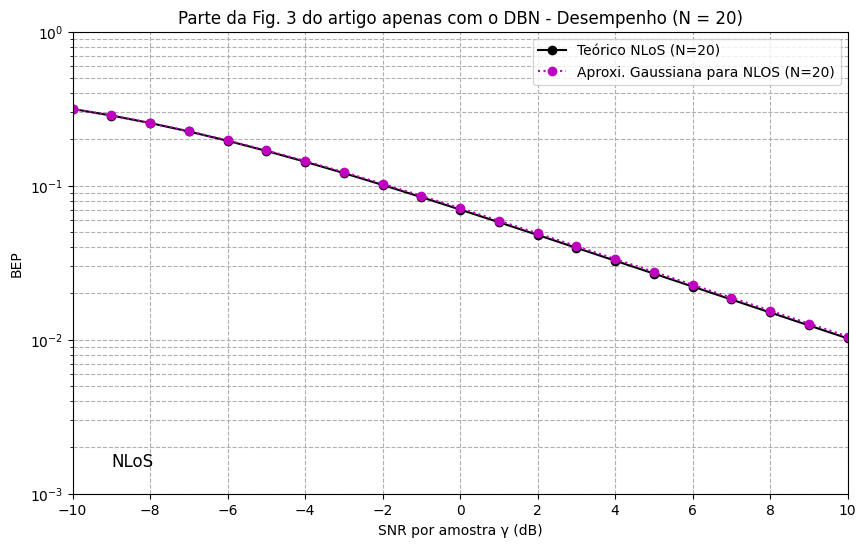

In [ ]:
# ==============================
# 6. Plot do nLoS                      fig 2 b)
# ==============================
plt.figure(figsize=(10, 6))

plt.semilogy(snr_db_range, ber_theo, 'ko-', label=f'Teórico NLoS (N={N})')  # 'cor + marcador + linha (opcional)'
#plt.semilogy(snr_db_range, ber_sim, 'ro--', label=f'Monte Carlo (N={N})')
plt.semilogy(snr_db_range, ber_appr, 'mo:', label=f'Aproxi. Gaussiana para NLOS (N={N})')

#  os^x+*d = circulo/quadrado/triangulo/X/mais/estrela/losango
#  bgrcmyk = azul/verde/vermelho/ciano/magenta/amarelo/preto
#  -/--/-./:   = continua/tracejada/traço-ponto/pontilhada

plt.grid(True, which='both', linestyle='--')
plt.xlabel('SNR por amostra γ (dB)')
plt.ylabel('BEP')
plt.title(f'Parte da Fig. 3 do artigo apenas com o DBN - Desempenho (N = {N})')
plt.legend()
plt.ylim(1e-3, 1) # Define o limite inferior do eixo Y para 10^-5 e o superior para 1
plt.xlim(-10, 10) # Define o limite inferior do eixo X para -10 e +10
plt.xticks(np.arange(-10, 11, 2)) # Define os ticks do eixo X de -10 a +10 com

plt.text(0.05, 0.05, 'NLoS', transform=plt.gca().transAxes,
         fontsize=12, verticalalignment='bottom', horizontalalignment='left')
# BEP seria para curvas analiticas (normalmente indica curvas continuas.)
# BER seria para monte carlos      (ou diz que é uma SIMULAÇAO BEP)
# Esse grafico não é o fig 3. A figura 3 usa o eixo x para variar N.

plt.show()



In [ ]:
#NLos

#NLoS conforme fig 3  b)     - Agora é para variar N



In [ ]:
# ==============================
# 1. Parâmetros do sistema nLoS
# ==============================
N_range = np.arange(50, 401, 50)                     # Amostras por símbolo (Processing Gain)
snr_db_1 = -5           #  artigo usa -10 e -5
num_bits = 10000           # Número de bits (Monte Carlo) 100mil é razoavel
# Sugestão de 5-10milhoes para erros na casa de 10^-5, contudo 1milhao já demora muito.

# ==============================
# 2. Função principal DBN para o NLoS
# ==============================


#ber_sim = [bep_teorica_dbn_nlos(N, snr) for snr in snr_db_range]  # snr é do for a frente diferente do snr_db que é um ESCALAR
# ????? ISSO É USADO AQUI . POR QUE ABAIXO USA DE NOVO . aCHO QUE NAO  É USADO ESSA
# ASSIM COMO NAO É USADO NO AWGN

In [ ]:
#  figura 3a) e b) CALCULA OS DOIS AQUI .   As funções sao as mesmas definidas no inicio do notebook
# ==============================
# 5. Simulação Monte Carlo e TEORICOS   AWGN   - aqui é a figura 3a) caso DBN
# ==============================
#ber_sim = []
#ber_appr = []
ber_theo_awgn = []
for N in N_range:
    print(f"Simulando N para AWGN = {N} dB...")

    #ber_sim.append(simulate_dbn(N, snr, num_bits))  # monte carlo
    #ber_appr.append(simpl_gauss_approx(N, snr))     # aprox gaussiana
    ber_theo_awgn.append(dbn_teorica_dbn(N, snr_db_1))     # snr aqui é apenas um valor. Agora N que varia



# ==============================
# 5. Simulação Monte Carlo e TEORICOS   nLoS - aqui é a figura 3b) caso DBN
# ==============================
#ber_sim = []
#ber_appr = []
ber_theo_nLos = []
for N in N_range:
    print(f"Simulando N para NLoS = {N} dB...")

    #ber_sim.append(simulate_dbn(N, snr, num_bits))  # monte carlo
    #ber_appr.append(simpl_gauss_approx(N, snr))     # aprox gaussiana
    ber_theo_nLos.append(bep_teorica_dbn_nlos(N, snr_db_1))     # teorica com integral   FUNÇÃO É : bep_teorica_dbn_nlos(N, snr_db)

Simulando N para AWGN = 50 dB...
Simulando N para AWGN = 100 dB...
Simulando N para AWGN = 150 dB...
Simulando N para AWGN = 200 dB...
Simulando N para AWGN = 250 dB...
Simulando N para AWGN = 300 dB...
Simulando N para AWGN = 350 dB...
Simulando N para AWGN = 400 dB...
Simulando N para NLoS = 50 dB...
Simulando N para NLoS = 100 dB...
Simulando N para NLoS = 150 dB...
Simulando N para NLoS = 200 dB...
Simulando N para NLoS = 250 dB...
Simulando N para NLoS = 300 dB...
Simulando N para NLoS = 350 dB...
Simulando N para NLoS = 400 dB...


In [ ]:
# Esse codigo abaixo é para o OODN função adaptada do codigo em matlab do professor G1_AWGN
# OODN para AWGN
import numpy as np
from scipy.special import erfc

# Função Q (equivalente ao qfunc do MATLAB)
def qfunc(x):
    return 0.5 * erfc(x / np.sqrt(2))

# ================================
# Parâmetros
# ================================

#num_bits = 100000  # alterei para ficar igual a usado para DBN
# vai buscar o valor definido no DBN acima

#N_range = np.arange(50, 401, 50)  # alterei para ficar igual a usado para DBN
# vai buscar o valor definido no DBN acima

sigma2w = 1       # É a variância do ruído branco (AWGN) do receptor

alpha = 10  # (não está sendo usado diretamente no código)

SNR_dB = np.arange(-10, 6, 1)
SNR_dB = np.array([snr_db_1])             # alterei para ficar igual a usado para DBN só 1 SNR e foramato de array
SNR_lin = 10**(SNR_dB / 10)               # DEFINIÇÃO   -->  SNR = sigma2b / sigma2w

# Matrizes de resultado
BER_sim_OODN = np.zeros((len(N_range), len(SNR_lin)))
BER_theo_OODN = np.zeros((len(N_range), len(SNR_lin)))

# ================================
# Simulação
# ================================
for n_idx, N in enumerate(N_range):

    for idx, gamma in enumerate(SNR_lin):
        #print(f"N={N}, SNR index={idx}")

        sigma2b = gamma * sigma2w  # variância (potência) média por bit necessária para atingir um determinado SNR
        sigma2b1 = 2 * sigma2b     # variância (potência) específica do bit 1. Como o bit 0 é silencio, assim a media por bit fica valida
                                   #   media do bit = ( potencia bit 1 + potencia bit 0 ) / 2   = (potencia bit 1 + 0)/2 = (potencia bit 1)/2

        # Limiar ótimo  chamado de lambda as vezes.
        gamma_opt_var = (2 * sigma2w * (sigma2w + sigma2b1)) / (2 * sigma2w + sigma2b1)

        # Bits transmitidos
        txBits = np.random.randint(0, 2, num_bits)
        rxBits = np.zeros(num_bits)

        for k in range(num_bits):

            if txBits[k] == 0:
                s_n = np.zeros(N, dtype=complex)
            else:
                s_n = np.sqrt(sigma2b1 / 2) * (
                    np.random.randn(N) + 1j * np.random.randn(N)
                )

            w_n = np.sqrt(sigma2w / 2) * (
                np.random.randn(N) + 1j * np.random.randn(N)
            )   # a função gera variancia unitaria para a parte real e imaginaria
                # assim ao multiplicar por raiz(sigma2w/2) normaliza para variancia total = 1
                #Variância é igual à Potência Média - média^2
                # Var(A* X  ) = A^2*Var(X)
                #   Quero que uma VA de tenha variancia "tal". Mas python so gera com "1", usando a propriedade se eu multiplicar por um "A" posso alterar
                #     Var(A* X  ) = metade para a parte real.  E similar a outra parte imaginaria ( o A sera o mesmo)
                #     Esse A quando sai da variancia vira A^2, assim tem-se A^2*(1) = "tal"
                #     logo A = raiz(tal)   como quero metade do tal para cada...
                # Var(total) = Var(real) + Var(imaginaria)
                # Python gera variancia unitaria e Var(X) = sigma2/2 e Var(Y) = sigma2/2 assim o total seria a soma "sigma2".
                # Ex: Para variancia total de 10 . O multiplicador deve ser raiz(10/2) = ~2,23.
                # Pois a parte real (2,23)^2 * 1 = 5
                # Pois a parte imag (2,23)^2 * 1 = 5

            x_n = s_n + w_n

            # Estimativa de variância
            estVar = np.mean(np.abs(x_n)**2)

            # Decisão
            if estVar < gamma_opt_var:
                rxBits[k] = 0
            else:
                rxBits[k] = 1

        # BER simulada
        BER_sim_OODN[n_idx, idx] = np.mean(rxBits != txBits)
        BER_sim_OODN[n_idx, idx] = np.sum(rxBits != txBits) / num_bits # equivalente

        # BER teórica
        BER_theo_OODN[n_idx, idx] = qfunc(np.sqrt(N) * (gamma / (1 + gamma)))
        #assume essa formula já que o limiar de decisão (lambda) é adotado como no
        # receptor como lambda = 2*sigma2w * (sigma2w + sigma2b1) / (2*sigma2w + sigma2b1)

    print(f"Concluído para N = {N}")

Concluído para N = 50
Concluído para N = 100
Concluído para N = 150
Concluído para N = 200
Concluído para N = 250
Concluído para N = 300
Concluído para N = 350
Concluído para N = 400


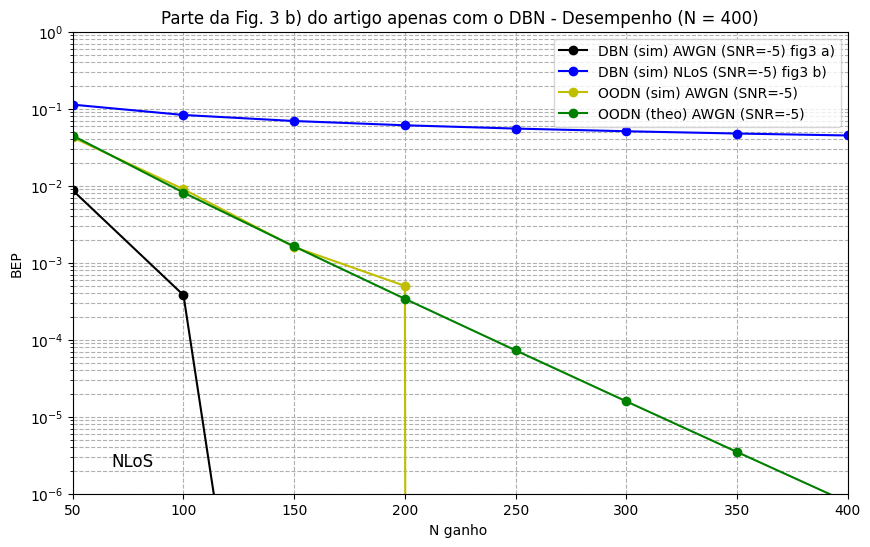

In [ ]:
# ==============================  Duas curvas al
# 6. Plot do nLoS para fig. 3 b) e a)  - Veja que foi gerado simulação do OODN AWGN (que foi adpatado do Matlab)
# ==============================
plt.figure(figsize=(10, 6))

plt.semilogy(N_range, ber_theo_awgn, 'ko-', label=f'DBN (sim) AWGN (SNR={snr_db_1}) fig3 a)')  # 'cor + marcador + linha (opcional)'   !!!! AQUI É O GRAFICO a)
plt.semilogy(N_range, ber_theo_nLos, 'bo-', label=f'DBN (sim) NLoS (SNR={snr_db_1}) fig3 b)')  # 'cor + marcador + linha (opcional)'   !!!! AQUI É O GRAFICO b)
#plt.semilogy(snr_db_range, ber_sim, 'ro--', label=f'Monte Carlo (N={N})')
#plt.semilogy(snr_db_range, ber_appr, 'mo:', label=f'Aproxi. Gaussiana (N={N})')
plt.semilogy(N_range, BER_sim_OODN, 'yo-', label=f'OODN (sim) AWGN (SNR={snr_db_1})')  #
plt.semilogy(N_range, BER_theo_OODN, 'go-', label=f'OODN (theo) AWGN (SNR={snr_db_1})')  #

#  os^x+*d = circulo/quadrado/triangulo/X/mais/estrela/losango
#  bgrcmyk = azul/verde/vermelho/ciano/magenta/amarelo/preto
#  -/--/-./:   = continua/tracejada/traço-ponto/pontilhada

plt.grid(True, which='both', linestyle='--')
plt.xlabel('N ganho ')
plt.ylabel('BEP')
plt.title(f'Parte da Fig. 3 b) do artigo apenas com o DBN - Desempenho (N = {N})')
plt.legend()
plt.ylim(1e-6, 1) # Define o limite inferior do eixo Y para 10^-5 e o superior para 1
plt.xlim(50, 400) # Define o limite inferior do eixo X para -10 e +10
#plt.xticks(np.arange(-10, 11, 2)) # Define os ticks do eixo X de -10 a +10 com
plt.xticks(np.arange(50, 401, 50))   # de 50 até 400, de 50 em 50

plt.text(0.05, 0.05, 'NLoS', transform=plt.gca().transAxes,
         fontsize=12, verticalalignment='bottom', horizontalalignment='left')
# BEP seria para curvas analiticas (normalmente indica curvas continuas.)
# BER seria para monte carlos      (ou diz que é uma SIMULAÇAO BEP)
# Esse grafico não é o fig 3. A figura 3 usa o eixo x para variar N.

plt.show()


# OODN só esta para AWGN . Ve se sera necessario para fading nLOS

In [ ]:
Agora a simulação para o outro artigo com DSTM.

SyntaxError: invalid syntax (168142463.py, line 1)

#T antenas - Artigo é MISO

# T antenas - Artigo é MISO


### Expansão para t antenas

## Conforme artigo de 2000.  Apesar de falar em MIMO as simulações sao em de MISO.

In [21]:
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, Math

In [2]:
# --- 1. Definição do Grupo de Quatérnios (Q8) ---
# Grupo de quartenarios :                  Q8​={±I,±i,±j,±k}
I = np.eye(2, dtype=complex)
g1 = np.array([[1j, 0],
               [0, -1j]], dtype=complex)
g2 = np.array([[0, -1],
               [1,  0]], dtype=complex)

g1g2 = g1 @ g2

# O alfabeto completo com 8 matrizes (3 bits por símbolo)
alphabet = [I,   -I,   g1, -g1,  g2,  -g2,  g1g2, -g1g2]  # sao matrizes!
#          [000 001   010  011  100   101   110    111]
#   101 binario  =   1 *(2^2) + 0* (2^1) + 1 *(2^0)  =  2^2 + 0 + 2^0 = 4+0+1 = 5  (ou sexto indice!!! 0-1-2-3-4-5)



# I → identidade
# g1 → representa i
# g2 → representa j
# g1g2 → representa k

'''cada matriz um SIMBOLO isso carrega 3 bits. G pertence a Q8
Passar de Q8 para DBN significa usar ruido e não matriz por isso
Grupo de Quatérnios (Q8), usado no artigo Diferencial spaco-time modulation  (Veja a Tabela I, R=1,5 para QPSK!!!!!!!!!!!)
R = log2(M) / t   [bits/s/Hz]   (para QPSK com t=2 antenas e r= 1 receptor) com distancia de produto minima = Λ_p 4
Relação entre QPSK e Q8: O QPSK fornece os "pontos" (os números 1,−1,j,−j), e o Grupo de Quatérnios organiza esses pontos em matrizes específicas para que duas antenas
possam transmitir juntas de forma eficiente sem precisar que o receptor conheça o canal (detecção diferencial)


A distância de produto mínima (Λ_p ) : é um critério fundamental de design para códigos de espaço-tempo, funcionando como um análogo matricial da distância de produto usada em canais de desvanecimento de antena única

x = s*u   com multiplas antenas fica   G_k = s_k * I e de forma mais avançada X_k​=G_k​⋅U  com U matriz de ruido (2xN)

Um bloco = uma transmissão de uma matriz X_k
escolhe um simbolo G_k  gera um X_K  recebe Y_k.
Veja que o calculo é da SER  = erros/n_blocos
n_blocos= 10k=ruim / 100k=ok / 500k=bom  / 1M+=artigo

Detector diferencial baseia-se premissa que o canal é IGUAL em blocos consectivos  (H_k  = H_k-1)
Garanta que, após trocar o canal, você envie um bloco de referência (como o X_0 )

distância de produto mínima (Λ_p ) veja tabela 1 do artigo
No detector diferencial ou coerente o objetivo é estimar a matriz G, mas preciso saber de G transmitido?
Na verdade o receptor sabe o alfabeto então ele testa cada matriz com a metrica e escolhe a que tiver o "max".
O DSTM testa as 8 matrizes para saber qual que se assemelha do alfabeto.

Resumo:
a)Dada um SNR. Define-se um "p" que é o inverso da SNR.
  A variancia do ruido(sinal) 	é definido como o inverso de "p"
b)Por conveniencia a variancia do ruido(canal)
  O canal (MISO com 2Tx e 1Rx) é definido como vetor (1,2) com distribuição Rayleing.
  O canal Rayleigh é usado porque ele modela bem a realidade de cenários sem linha de visada (NLOS)
  Teorema Central do Limite =  h ~ N(0,sigma^2)    Rayleigh é um cenário difícil!
c)Modelo canal é Y = HX_0 + W_0
  Veja que a simulação ocorre por blocos. A cada bloco é escolhido aleatoriamente uma MATRIZ G que esta associado a uma sequencia de bits
  1) SE for multiplo de 100 ( no ciclo de 0, 100, 200, etc...)
    Novo canal então reinicia o X_0, e Y_o e ativa o skip_next
    X_0 muda a caa
  2) SE for OVERHEAD
    gera um X_1 e um Y_1. Não detecta esse erro???
  3) Cria o sinal a ser transmitido usando a matriz pertecente a Q8, esse sinal passa pelo canal H e soma-se ao ruido
  4) Detector diferencial (sem CSI) cria a matriz M com Y_atual e Y_anterior
    Aplica-se a metrica que envolve traço, matriz G e matriz M para achar G estimado.
  5) Detector coerente (usa H) calcula achar G estimado
  6) Atualiza X_anterior e Y_anterior
  7) Conta os erro por simbolos SER


'''







'cada matriz um SIMBOLO isso carrega 3 bits. G pertence a Q8\nPassar de Q8 para DBN significa usar ruido e não matriz por isso\nGrupo de Quatérnios (Q8), usado no artigo Diferencial spaco-time modulation  (Veja a Tabela I, R=1,5 para QPSK!!!!!!!!!!!)\nR = log2(M) / t   [bits/s/Hz]   (para QPSK com t=2 antenas e r= 1 receptor) com distancia de produto minima = Λ_p 4\nRelação entre QPSK e Q8: O QPSK fornece os "pontos" (os números 1,−1,j,−j), e o Grupo de Quatérnios organiza esses pontos em matrizes específicas para que duas antenas\npossam transmitir juntas de forma eficiente sem precisar que o receptor conheça o canal (detecção diferencial)\n\n\nA distância de produto mínima (Λ_p ) : é um critério fundamental de design para códigos de espaço-tempo, funcionando como um análogo matricial da distância de produto usada em canais de desvanecimento de antena única\n\nx = s*u   com multiplas antenas fica   G_k = s_k * I e de forma mais avançada X_k\u200b=G_k\u200b⋅U  com U matriz de ruido (2x

In [3]:
print(g1.shape)
print(g1.dtype)

(2, 2)
complex128


In [42]:
# so teste da anterior
# Deve ser unitaria   =    G_k^H  * G_k  = I
#teste1 = -I@-I

# 111111111111111111111111111111111111111111111111111111111111111111111111111111
# Matriz UNITÁRIA  (veja que é diferente de IDENTIDADE)
############## Um alfabeto por ele mesmo (Hermetiano dá a identidade)
i = 0     # teste para todos os indice da a identidade, aqui é para o primeiro
print("1 - Matriz escolhida -indice ",i," : ")
print("")
print(alphabet[i])
print("")
teste2 = alphabet[i].conj().T@alphabet[i]      #
print("2 - Matriz unitária é diferente de IDENTIDADE")
print(teste2)
print("Tipos de dados",teste2.dtype)
print("")

#33333333333333333333333333333333333333333333333333333333333333333333333333333
# Determinante de cada alfabeto    = Sempre igual a 1
teste3 = np.linalg.det(alphabet[i])
print("3 - Determinante de cada alfabeto")
print(teste3)
print("")

# Distancia produto
print("4 - Sobre distancia dos produtos") # Usa a metrica Norma de Frobenius
# O 'r' no início é fundamental para o Python não interpretar as barras invertidas
display(Math(r'\|A\|_F = \sqrt{\sum_{i=1}^m \sum_{j=1}^n |a_{ij}|^2 }'))
print("Definição da Norma de Frobenius")   # Ela mede a Energia ou a Distância Euclidiana entre duas matrizes.
#print(np.linalg.norm(alphabet[i], ord='fro'))

# Distancia entre matrizes
print("")
print("5 - Distancia entre matrizes")
display(Math(r'\text{dist}(X, Y) = \|X - Y\|_F'))

# Calculo em python
print("")
print("     5.1 - Calculo em python:")
print("     Eq. : ", "np.linalg.norm(X - Y, 'fro')")
print("")
print("     5.2 - Exemplo:")
j = 1
teste4 = np.linalg.norm(alphabet[i] - alphabet[j], 'fro')
print("Valor em python: ", "[i,j] : ", i, j, " = ",teste4)
print("O conceito 4 e 5 não são usados no artigo e sim outro abaixo")
#???????????????????????????? NAO USAR 4 E 5 , MAS É BOM LEMBRAR DOS CONCEITOS

# 666666666666666666666666666666666666666666666666666666666666666666666
# Distancia de produto  - Determinante
print("")                   # A distância de produto entre dois símbolos $G_a$ e $G_b$ é o valor absoluto do determinante da matriz de erro:
# mede a Capacidade de Distinção das matrizes sob desvanecimento (Fading)
# É a métrica que define o Ganho de Codificação. Em canais Rayleigh, a probabilidade de erro é inversamente proporcional a essa distância de produto.
# Se o determinante da diferença for zero, seu sistema perde "diversidade total" e o desempenho despenca.
print("6 - Distancia de Produto")
display(Math(r'd_p(G_a, G_b) = |\det(G_a - G_b)|'))  # nao sei se vale para matrizes nao quadradas!!!!!
diff = alphabet[0] - alphabet[1]
dist_produto = np.abs(np.linalg.det(diff))
print(f"Distância de Produto: {dist_produto}") # Resultado: 4.0

# 7777777777777777777777777777777777777777777777777777777777777777777777
# 7  ###########################################################
# Inicializa uma matriz para guardar os resultados (8x8)
n = len(alphabet)
dist_matrix = np.zeros((n, n))

print("---  7- Cálculo das Distâncias de Produto ---")

for i in range(n):
    for j in range(i + 1, n):  # Começa em i+1 para evitar a diagonal e repetições
        diff = alphabet[i] - alphabet[j]
        dist_prod = np.abs(np.linalg.det(diff))

        # Como a distância é simétrica, preenchemos ambos os lados
        dist_matrix[i, j] = dist_prod
        dist_matrix[j, i] = dist_prod

        # Print opcional para depuração (pode comentar se o alfabeto for grande)
        # print(f"Distância entre G{i} e G{j}: {dist_prod:.2f}")

# Exibindo a matriz de forma organizada
print("\nMatriz de Distâncias de Produto (Resumo):")
print(dist_matrix)

# Calculando a Distância de Produto Mínima (Zeta)
# Pegamos apenas os valores acima de zero
dist_minima = np.min(dist_matrix[dist_matrix > 0])
print(f"\nDistância de Produto Mínima do Alfabeto (ζ): {dist_minima}")

# 8   Notações diferentes
print("")
print("8 - Notações diferentes")
display(Math(r'\Lambda_p vs. \zeta'))  #
# Muitos artigos utilizam $\Lambda_p$ para representar a distância de produto ao quadrado ou escalonada.
display(Math(r'\Lambda_p = \min_{a \neq b} |\det(G_a - G_b)|^2'))  #



# Conclusões do testes
# 2 Lembre-se que matriz unitaria é uma coisa e não quer dizer identidade
# 3 Nos quaternios Q8 cada elemento do alfabeto tem determinante = 1.
# 4 E 5 Distancia usando Norma de Frobenius que esta errada para sistema MIMO . Ex matriz diferença [ 2 0 ; 0 0]. Pela norma da uma distancia 2, mas MIMO é zero (veja abaixo)
# 6 e 7 Distancia produto pelo DETERMINANTE o calculo correto, contudo aqui é de uma forma LINEAR letra zeta minuscula (difernte da tabela I quaternios Q8 para R = 1,5 QPSK)
# 8 Apenas um esclarecimento entre Lambda maiusculo (metrica quadratica) e zeta minusculo como a matrica linear
#            Distância de Produto Mínima do Alfabeto (ζ)   = linear
#            Distância de Produto Mínima do Alfabeto (Λ_p) = quadratica


1 - Matriz escolhida -indice  0  : 

[[1.+0.j 0.+0.j]
 [0.+0.j 1.+0.j]]

2 - Matriz unitária é diferente de IDENTIDADE
[[1.+0.j 0.+0.j]
 [0.+0.j 1.+0.j]]
Tipos de dados complex128

3 - Determinante de cada alfabeto
(1+0j)

4 - Sobre distancia dos produtos


<IPython.core.display.Math object>

Definição da Norma de Frobenius

5 - Distancia entre matrizes


<IPython.core.display.Math object>


     5.1 - Calculo em python:
     Eq. :  np.linalg.norm(X - Y, 'fro')

     5.2 - Exemplo:
Valor em python:  [i,j] :  0 1  =  2.8284271247461903
O conceito 4 e 5 não são usados no artigo e sim outro abaixo

6 - Distancia de Produto


<IPython.core.display.Math object>

Distância de Produto: 4.0
---  7- Cálculo das Distâncias de Produto ---

Matriz de Distâncias de Produto (Resumo):
[[0. 4. 2. 2. 2. 2. 2. 2.]
 [4. 0. 2. 2. 2. 2. 2. 2.]
 [2. 2. 0. 4. 2. 2. 2. 2.]
 [2. 2. 4. 0. 2. 2. 2. 2.]
 [2. 2. 2. 2. 0. 4. 2. 2.]
 [2. 2. 2. 2. 4. 0. 2. 2.]
 [2. 2. 2. 2. 2. 2. 0. 4.]
 [2. 2. 2. 2. 2. 2. 4. 0.]]

Distância de Produto Mínima do Alfabeto (ζ): 1.9999999999999996

8 - Notações diferentes


<IPython.core.display.Math object>

<IPython.core.display.Math object>

    # SNR per receive antenna (rho no artigo)
    # Fig 3 usa r=1 (Uma única antena receptora)
    A eficiencia espectral é definida como
    # Artigo assume que N será chamado de n=t (bloco quadrado sendo t numero antenas em Tx)

In [ ]:
# H não é unitaria e sim um vetor de GANHO DE CAMINHOS
H = (np.random.randn(1, 2) + 1j*np.random.randn(1, 2)) / np.sqrt(2)
norm_H = np.linalg.norm(H)   # norma padrao EUCLIDIANA de um vetor
print(norm_H)
norm_H2 = np.linalg.norm(H)**2 # norma usada em comunicações pois SNR_efetiva = SNR * norm_H2
print(norm_H2)
print("Esses valores acima são apenas para uma AMOSTRA")
N = 100000
vals = []

for _ in range(N):
    H = (np.random.randn(1, 2) + 1j*np.random.randn(1, 2)) / np.sqrt(2)
    vals.append(np.sum(np.abs(H)**2))

print("Média para VARIAS AMOSTRAS:", np.mean(vals))
print("Média de norma(H^2) é igual ao numero de antenas!")
print("")
print("")
'''
Para 1 antena
H = [h ]
h~CN(0,1)
h = (X+jY) / raiz(2) com X e Y ~N(0,1)
modulo de h^2 = (X^2 + Y^2)/2  = 1 sabendo que como X^2 + Y^2 = 2

Para 2 antenas
H = [h1 , h2]
logo a media do vetor H^2 sera N antenas
'''

1.1361221036603055
1.290773434425518
Esses valores acima são apenas para uma AMOSTRA
Média para VARIAS AMOSTRAS: 1.9994217875963258
Média de norma(H^2) é igual ao numero de antenas!




'\nPara 1 antena\nH = [h ]\nh~CN(0,1)\nh = (X+jY) / raiz(2) com X e Y ~N(0,1)\nmodulo de h^2 = (X^2 + Y^2)/2  = 1 sabendo que como X^2 + Y^2 = 2\n\nPara 2 antenas\nH = [h1 , h2]\nlogo a media do vetor H^2 sera N antenas\n'

In [ ]:
# Essa função serve para teste G e X se são unitarios
'''G e X devem ser matrizes unitaria
G deve satisfazer G^H*G = I           = aqui é matriz unitaria pois gera matriz IDENTIDADE
X_0^H*X_0 = 0.5I                      = aqui é matriz normalizada (potencia = 1)
'''

def is_unitary(matrix, scale=1.0):
    # Calcula a transposta conjugada (H)
    matrix_h = matrix.conj().T

    # Realiza o produto matricial
    product = matrix_h @ matrix

    # Define a Identidade esperada (multiplicada pela escala, se houver)
    identity = scale * np.eye(matrix.shape)

    # Verifica se os valores são próximos (devido a precisão de ponto flutuante)
    return np.allclose(product, identity)

# Exemplo de teste para uma matriz G do seu alfabeto:
# print(is_unitary(alphabet)) # Deve retornar True

# Exemplo de teste para sua X_0 (Eq. 22 de Hughes):
# print(is_unitary(X_prev, scale=0.5)) # Deve retornar True

In [ ]:
#

In [44]:
def run_simulation_miso(snr_db_range, num_blocks):

    ser_diff = []
    ser_coh = []
    ber_diff = []
    ber_coh = []

    for i, snr_db in enumerate(snr_db_range):

        print(f"[{i+1}/{len(snr_db_range)}] SNR = {snr_db} dB")

        rho = 10**(snr_db / 10)      # ρ_t = ρ/2 (SNR/antena)   (rho é a SNR!). Duvida acho que o 2 aqui é para dividir por t antenas.
        sigma_w2 = 1.0 / (2*rho)    #  variância do ruído como inversamente proporcional ao SNR (ρ)
        ########### TESTE101 NA LINHA ABAIXO
        #sigma_w2 = 0     # teste é como se SNR fosse infinita -  Leva o ruido a ser insignificante
        # matrizes de quatérnios são unitárias e o canal H é constante entre os dois blocos a metrica
        # Re Tr{GM} deve ser maxima exatamente na G enviada.
        # Resp1: O resultado que você obteve é muito revelador. O fato de o BER Coerente ser 0.0 com ruído zero prova que sua geração de canal (H), o seu alfabeto de Quatérnios (G)
        #        e a sua codificação estão funcionando perfeitamente.
        #        ou seja G e H estão respeitando os criterios de geração. O fato de BER ou SER apresentar erro (~~1/8 ) indica erro na logico do receptor diferencial apenas.
        ########### TESTE101 NA LINHA ABAIXO

        errors_diff = 0
        errors_coh = 0
        errors_diff_BER = 0
        errors_coh_BER = 0
        valid_blocks = 0

        # Canal inicial (MISO 1x2)
        #H = (np.random.randn(1, 2) + 1j*np.random.randn(1, 2)) / np.sqrt(2)
        # usar esse  H abaixo para depurar (considerando o ruido zero com SNR ao infinito)
        seed = 42 # Define a semente (pode ser qualquer número inteiro)
        rng = np.random.default_rng(seed)
        # Agora use rng.standard_normal ou rng.normal em vez de np.random.randn
        H = (rng.standard_normal((1, 2)) + 1j * rng.standard_normal((1, 2))) / np.sqrt(2)  # sqrt(2) é normatizar potencia.
                                                                         # standart_normal = sigma2 = 1 ai fica H=1 + 1 = 2
                                                                        # para variancia de H=2 ser unitaria divide por raiz(2)!
        # respeita o modelo de desvanecimento Rayleigh
        # |H| = \sqrt{X^2 + Y^2} segue exatamente uma Distribuição Rayleigh apesar de X e Y forem geradas Gaussianas (0,1)
        # H é uniformemente distribuída entre 0 e
        # DSTM, trabalhamos majoritariamente com Rayleigh porque é onde a modulação diferencial brilha, lidando com a mudança constante de fase dessas componentes aleatórias.


        # X0 (Eq. 22)
        X_prev = (1/np.sqrt(2)) * np.eye(2, dtype=complex)  # Essa é a X_0 / np.eye = identidade e srqt(2) é para normalizar.
        # sqrt(2) = aqui é para normalizar cada antena tem potencia = 1, logo para t=2 usa-se sqrt(2). Se fosse 3 seria sqrt(3)!!!

        # Primeira observação (referência)
        noise = np.sqrt(sigma_w2/2) * (np.random.randn(1, 2) + 1j*np.random.randn(1, 2)) #normaliza a variancia total (real+imag)
        Y_prev = H @ X_prev + noise    # Canal Rayleigh + ruido AWGN

        skip_next = False  # controle do overhead extra


        # O canal H deve ser mantido constante por pelo menos dois blocos (o atual e o anterior)
        # Essa é uma premissa
        # cada bloco é uma simulação de Monte Carlo
        for k in range(num_blocks):

            # ==========================
            # Troca de canal (block fading)
            # ==========================
            # Vai fazer esse proximo if a cada 100; 200; 300...  ou seja na troca a CADA 100 blocos ( L =100 foi definido) !!!!
            # Gera um novo canal, novo X_0 e novo Y_0 e tag "skip_nex" indica que
            if k % 100 == 0 and k > 0:       # (resto da divisão por 100)  E  (verifica se é ZERO )Logo é multiplo de 100!
                H = (np.random.randn(1, 2) + 1j*np.random.randn(1, 2)) / np.sqrt(2)

                # reinicializa referência
                X_prev = (1/np.sqrt(2)) * np.eye(2, dtype=complex)
                noise = np.sqrt(sigma_w2/2) * (np.random.randn(1, 2) + 1j*np.random.randn(1, 2))
                Y_prev = H @ X_prev + noise

                skip_next = True
                continue    # pula o resto do codigo e vai proximo contagem! Ex tava em 100. Vai pra 101.

            # ==========================
            # bloco após reset (não detecta) Sera sempro o 101; 201; 301 ...
            # ==========================
            if skip_next:
                idx = np.random.randint(0, 8)
                #idx = 0      # ESSA LINHA DEVE SER APAGADA APENAS UM TESTE PARA SABER SE HA ERRO EM UMA MATRIZ ESPECIFICA! JUNTO COM O TESTE101
                G_true = alphabet[idx]

                # nao usar X_curr =  X_prev @ G_true  # multiplicar pela direita   Y_k = (H X_k-1)G  = Y_k @ G = correto
                X_curr =   X_prev @ G_true      # Eq 13 ok

                noise = np.sqrt(sigma_w2/2) * (np.random.randn(1, 2) + 1j*np.random.randn(1, 2))
                Y_curr = H @ X_curr + noise

                X_prev = X_curr
                Y_prev = Y_curr

                skip_next = False
                continue  # pula o resto do codigo e vai proximo contagem!
                # Veja que o valid_block só é contabilizado de 102 até 199
                #

            # ==========================
            # símbolo normal
            # ==========================
            idx = np.random.randint(0, 8)
            #padrao = [5, 2, 3, 7]
            #idx = padrao[k]      # ESSA LINHA DEVE SER APAGADA APENAS UM TESTE PARA SABER SE HA ERRO EM UMA MATRIZ ESPECIFICA! JUNTO COM O TESTE101
            G_true = alphabet[idx]

            # Codificação diferencial (Eq. 13)
            # nao usar X_curr =  X_prev @ G_true  # multiplicar pela direita   Y_k = (H X_k-1)G  = Y_k @ G = correto
            X_curr =   X_prev @ G_true
            # print("X_prev = ", X_prev)
            # print("")
            # print("G_true = ", G_true)
            # print("")
            # print("X_curr = ", X_curr)
            # print("")

            # Canal
            noise = np.sqrt(sigma_w2/2) * (np.random.randn(1, 2) + 1j*np.random.randn(1, 2))
            Y_curr = H @ X_curr + noise
            # print("noise =", noise)
            # print("")
            # print("H = ", H)
            # print("")
            # print("Y_curr = ", Y_curr)
            # print("")

            # ==========================
            # DETECTOR DIFERENCIAL (Eq. 16)
            # ==========================
            M = Y_curr.conj().T @ Y_prev  # (2x2)  M sozinho não é potencia! É matriz de correlação cruzada (curr e prev)!    "M = Memoria Diferencial"  = quanto o sinal mudou (em fase e amplitude)
            # adjunta é transposta e conjugada.!
            # print("M = ", M)
            # print("")

            # G @ M é a "assinatura" do canal que ficou guardada em $M$ e tentando desfazer a rotação usando uma matriz do seu alfabeto $G$
            # Se $G$ for a matriz correta (aquela que foi realmente enviada), o produto $G M$ resultará em uma matriz onde os elementos da diagonal principal são reforçados (somados construtivamente).
            # É como se $M$ fosse um vetor de energia vindo do canal e você estivesse testando qual $G$ consegue capturar a maior parte dessa potência para a parte real.

            # O traço é a soma dos elementos da diagonal. No contexto de detecção:
            #       O traço funciona como um filtro casado (matched filter).
            #       Ele extrai a "coerência" entre a hipótese $G$ e a observação $M$.Valor Máximo:
            #       O traço de $G M$ será máximo quando a fase e a orientação de $G$ "alinharem" perfeitamente com a defasagem contida em $M$
            # Conclusão no DSTM, o detector busca a matriz que maximiza a projeção de energia na direção correta!!!!!!!!!!!!!!!!!!!

            metrics_diff = []
            for G in alphabet:     # vai testar cada uma das matrizes
                #val = np.real(np.trace(G.conj().T @ M))   # parece que .conj().T  gera erro na inversão de fase ao fazer o trace idx 2 ate 7 gera erro de 1/3 sem ruido sigma_w2 = 0
                val = np.real(np.trace(G @ M))
                metrics_diff.append(float(val))

            idx_hat_diff = np.argmax(metrics_diff)
            # print("metrics_diff = ", metrics_diff)
            # print("")

            # pega o indice que deu o maior valor sera o indice de G ESTIMADO/CHAPEU

            # ==========================
            # DETECTOR COERENTE
            # ==========================
            metrics_coh = []
            for G in alphabet:
                X_test =  X_prev @ G
                diff_vec = Y_curr - H @ X_test
                val = -np.sum(np.abs(diff_vec)**2)
                metrics_coh.append(float(val))

            idx_hat_coh = np.argmax(metrics_coh)

            # ==========================
            # contagem de erros de simbolos
            # ==========================
            if idx_hat_diff != idx:
                errors_diff += 1

            if idx_hat_coh != idx:
                errors_coh += 1


            # print("k= ",k,"traço= ",metrics_diff, "idx da metrics é= ", idx_hat_diff, "idx de G_true é= ",idx)     # TESTE 201 AGORA SABENDO ONDE OCORRE O ERRO APOS O TESTE101
            # print("Contagem de erro por look k = ", errors_diff)


            # Para simbolos = SER
            valid_blocks += 1              # Cada simbolo valido  (0 ate 99 = 100 simbolos, depois perde 100 e 101 e conta 102 até 199 = 98). Logo são 100+99+98+98+...




            # ==========================
            # contagem de erros de bit
            # ==========================
            # R = 1,5 é eficiencia expectral     (R = log2(M)/n) M numero de matrizes e n comprimento do bloco (t=2 e n=2)
            bit_errors_diff = bin(idx_hat_diff ^ idx).count('1')  #considerando 3 bits por símbolo
            # O Operador XOR (^) : iguais = 0 e diferente =1 /  A Função bin(): passa de decimal para "string binária" / O Método .count('1'): conta /
            errors_diff_BER += bit_errors_diff

            bit_errors_coh = bin(idx_hat_coh ^ idx).count('1')  #considerando 3 bits por símbolo
            errors_coh_BER += bit_errors_coh

            # Para bits = BER
            total_bits = 3 * valid_blocks  # Cada símbolo válido carrega 3 bits           Cada simbolo tem 3 bits

            #============================
            # atualização temporal
            X_prev = X_curr
            Y_prev = Y_curr

        # teste
        #   print(f"       SNR é {snr_db} e bloco validos total é {valid_blocks} ")
        # Dica no primeiro bloco de canal todos os são validos (k:) 0,1,2...99 = 100 blocos
        # Depois no k=100 inicia um canal novo - atualiza parametro, mas pula o resto do codigo "continue"  (atualiza H, X_0, ruido =  Y_0    )
        # Depois no k=101 atualiza o X_0/ Y_0 e etc e pula o resto do codigo "continue"                     (atualiza X_atual, ruido = Y_atual)

        ser_diff.append(errors_diff / valid_blocks)
        ser_coh.append(errors_coh / valid_blocks)

        ber_diff.append(errors_diff_BER / total_bits)
        ber_coh.append(errors_coh_BER / total_bits)

    print("✅ Simulação concluída!")

    return ser_diff, ser_coh, ber_diff, ber_coh

[1/7] SNR = 5.0 dB
[2/7] SNR = 7.5 dB
[3/7] SNR = 10.0 dB
[4/7] SNR = 12.5 dB
[5/7] SNR = 15.0 dB
[6/7] SNR = 17.5 dB
[7/7] SNR = 20.0 dB
✅ Simulação concluída!


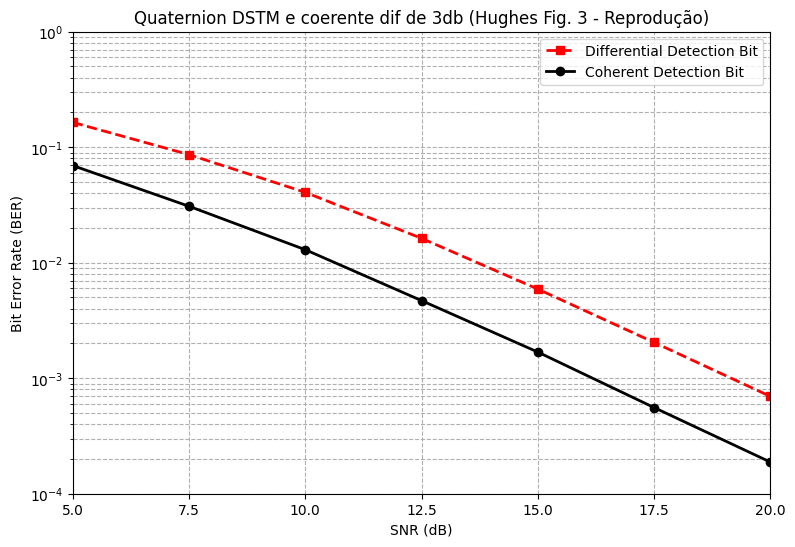

'\nDeve haver uma curva similar com 3db de diferença.\nArtigo "Differential Space–Time Modulation, november 2000"\n\n'

In [ ]:
# --- Execução e Plotagem ---

snr_range = np.arange(5, 21, 2.5)

ser_diff, ser_coh, ber_diff, ber_coh = run_simulation_miso(snr_range, num_blocks=100000) # 10k=ruim / 100k=ok / 500k=bom  / 1M+=artigo
                                                                                          #            3mi                    30min

plt.figure(figsize=(9,6))

#plt.semilogy(snr_range, ser_diff, 'r--s', linewidth=2, markersize=6, label='Differential Detection Simbolo')
#plt.semilogy(snr_range, ser_coh, 'b--o', linewidth=2, markersize=6, label='Coherent Detection Simbolo')
plt.semilogy(snr_range, ber_diff, 'r--s', linewidth=2, markersize=6, label='Differential Detection Bit')
plt.semilogy(snr_range, ber_coh, 'k-o', linewidth=2, markersize=6, label='Coherent Detection Bit')

plt.grid(True, which="both", linestyle='--')
plt.xlabel('SNR (dB)')
plt.ylabel('Bit Error Rate (BER)')
plt.title('Quaternion DSTM e coerente dif de 3db (Hughes Fig. 3 - Reprodução)')
plt.ylim(1e-4, 1e-0)
plt.xticks(np.arange(5, 21, 2.5))   # de 50 até 400, de 50 em 50
plt.xlim(5, 20)
plt.legend()

plt.show()
'''
Deve haver uma curva similar com 3db de diferença.
Artigo "Differential Space–Time Modulation, november 2000"

'''


In [ ]:
print(ser_diff)
print(ser_coh)
print(ber_diff)
print(ber_coh)

# DSTNM  - COM MATRIZ DE RUÍDO

# **DSTNM**


# Objetivos:

## DBN
Ok = Feito AWGN e nLOS  (SNR e N)

## DSTM
Ok = Feito diferencial e coerente (SNR)

## DSTNM
?? = Fazer para diferencial, depois coerente, 3dB?

## Juntar DBN e DSTNM
?? = Falta fazer isso.

In [45]:
# DSTNM
import numpy as np
from IPython.display import display, Math    # para mostrar um formula nao serve usar o print melhor o display

import matplotlib.pyplot as plt
from scipy import integrate, stats, special
from scipy.special import erfc



In [34]:
# A ideia agora é retirar a matriz IDENTIDADE e usar matriz de ruido (UNITARIA E NORMALIZADA).
#1) Antes a identidade normalizada era:
# X0 (Eq. 22)
X_prev = (1/np.sqrt(2)) * np.eye(2, dtype=complex)  # Essa é a X_0 / np.eye = identidade e srqt(2) é para normalizar.
# sqrt(2) = aqui é para normalizar cada antena tem potencia = 1, logo para t=2 usa-se sqrt(2). Se fosse 3 seria sqrt(3)!!!

#2) Agora para essa matriz ser um ruido inicial e normalizao ficará:
# Para que uma matriz seja considerada unitária, ela deve satisfazer a condição $A^H A = I$, onde $A^H$ é a transposta hermitiana (transposta e conjugada) e $I$ é a identidade.
sigma_noise2 = 0.1
# np.random.normal(media, desvio_padrao, tamanho)
# O desvio padrão é a raiz da variância (sqrt(sigma2 / 2))  # metade para a parte real e metade na imaginaria
shape = (2, 2)
noise_real = np.random.normal(0, np.sqrt(sigma_noise2 / 2), shape)
noise_imag = np.random.normal(0, np.sqrt(sigma_noise2 / 2), shape)
N = noise_real + 1j * noise_imag

print("Matriz de Ruído Original (N):\n", N)
print("Potência total medida (tr(N^H N)):", np.trace(np.dot(N.conj().T, N)).real)
print("Potencia total medida $\sum_{i,j} |a_{i,j}|^2$ : ",  np.sum(np.abs(N)**2)) #
# np.abs(N)**2 calcula o quadrado do módulo de cada elemento individualmente
# .sum() soma todos eles
print("")
# Normalização da matriz identidade
# Dividimos pela norma de Frobenius (raiz do traço de N^H * N)
norma = np.linalg.norm(N)
N_normalized = N / norma


print("\nMatriz Normalizada (N_normalized):\n", N_normalized)
print("Nova Potência total (deve ser 1.0):", np.trace(np.dot(N_normalized.conj().T, N_normalized)).real)
print("Potencia total medida $\sum_{i,j} |a_{i,j}|^2$ : ",  np.sum(np.abs(N_normalized)**2)) #
# np.abs(N)**2 calcula o quadrado do módulo de cada elemento individualmente
# .sum() soma todos eles
# abaixo usando "DISPLAY" apenas para aparecer a formaçatação LATEX
print("")
resultado = np.sum(np.abs(N_normalized)**2)
# Usando f-string para inserir a variável dentro do LaTeX
display(Math(f'\\text{{Potência total medida }} \\sum_{{i,j}} |a_{{i,j}}|^2: {resultado}'))    # \\sum ou r'\sum'
print("")


###############################################################
# Resumo de matriz unitaria
# 1) Ortogonalidade das colunas (e linhas): produto de qq coluna deve ser ZERO
# 2) Normalização: norma de qq coluna (comprimento) = 1
# 3) Preservação energia: Norma Frobenius a soma de todos elementos ao quadrado é igual a n (dado uma matriz nxn)
# 4) Determinante: valor absoluto é igual a 1.
###############################################################
# Resumo 2
#Visualmente, você pode notar que as colunas de uma matriz unitária devem ser ortonormais entre si (ter norma 1 e serem perpendiculares), o que não ocorre aqui.
# 1) propriedade: $$\text{tr}(U^H U) = \text{tr}(I_n) = n$$ . Soma dos valores diagonal principal é o traço.
# 2) Norma de Frobenius  e energia:
# $$\|A\|_F^2 = \text{tr}(A^H A) = \sum_{i,j} |a_{i,j}|^2$$
###############################################################


Matriz de Ruído Original (N):
 [[ 0.23728955+0.42206787j -0.1664509 -0.51810517j]
 [ 0.20085696-0.07764428j -0.04369598-0.06396137j]]
Potência total medida (tr(N^H N)): 0.5829590463799463
Potencia total medida $\sum_{i,j} |a_{i,j}|^2$ :  0.5829590463799464


Matriz Normalizada (N_normalized):
 [[ 0.31078467+0.55279394j -0.21800534-0.67857664j]
 [ 0.26306791-0.10169285j -0.05722983-0.08377197j]]
Nova Potência total (deve ser 1.0): 1.0
Potencia total medida $\sum_{i,j} |a_{i,j}|^2$ :  0.9999999999999999



<>:19: SyntaxWarning: invalid escape sequence '\s'
<>:31: SyntaxWarning: invalid escape sequence '\s'
<>:19: SyntaxWarning: invalid escape sequence '\s'
<>:31: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_13882/2870606418.py:19: SyntaxWarning: invalid escape sequence '\s'
  print("Potencia total medida $\sum_{i,j} |a_{i,j}|^2$ : ",  np.sum(np.abs(N)**2)) #
/tmp/ipykernel_13882/2870606418.py:31: SyntaxWarning: invalid escape sequence '\s'
  print("Potencia total medida $\sum_{i,j} |a_{i,j}|^2$ : ",  np.sum(np.abs(N_normalized)**2)) #


<IPython.core.display.Math object>

In [36]:
# teste 1 #####################################################################
np.eye(3)  # gera matriz IDENTIDADE 3X3


# teste 2 #####################################################################
import numpy as np

# 1. Gerar uma matriz aleatória complexa 2x2
A = (np.random.randn(2, 2) + 1j * np.random.randn(2, 2))

# 2. Decomposição QR para torná-la unitária (Q^H * Q = I)
# Isso garante que as colunas sejam ortogonais e tenham norma 1
Q, R = np.linalg.qr(A)

# 3. Normalizar a potência total para 1
# Como Q é unitária 2x2, a potência de Q é tr(Q^H Q) = tr(I_2) = 2.
# Para que a potência total seja 1, multiplicamos por 1/sqrt(2).
X_prev = (1/np.sqrt(2)) * Q

# --- Verificações ---
print("Potência Total (deve ser 1.0):", np.sum(np.abs(X_prev)**2))
print("É unitária? (deve ser I_2/2):\n", np.round(X_prev.conj().T @ X_prev, 10))
# A multiplicação A^H * A  = I  (mas isso gera potencia n dado que I é de tamanho nxn)
# Como a potencia foi normalizada não vai sair o I e sim algo normalizado (pot = 1)
# Se fosse matriz 3x3 o calculo acima seri I/3!

############ RESUMO 1
# linalg = Linear Algebra
# Q = Matriz Ortogonal (colunas sao vetores UNITARIOS e PERPENDICULARES entre si)
# R = Matriz triangular superior (todos elementos abaixo da diagonal principal sao ZEROS)



Potência Total (deve ser 1.0): 0.9999999999999997
É unitária? (deve ser I_2/2):
 [[0.5+0.j 0. +0.j]
 [0. -0.j 0.5+0.j]]


In [37]:
Q, R = np.linalg.qr((np.random.randn(2, 2) + 1j * np.random.randn(2, 2)))
X_prev = (1/np.sqrt(2)) * Q
print("Potência Total (deve ser 1.0):", np.sum(np.abs(X_prev)**2))
print("É unitária? (deve ser I_2/2):\n", np.round(X_prev.conj().T @ X_prev, 10))

Potência Total (deve ser 1.0): 0.9999999999999999
É unitária? (deve ser I_2/2):
 [[0.5+0.j 0. +0.j]
 [0. +0.j 0.5+0.j]]


In [141]:
# A segundo ideia agora é retirar o alfabeto e deixar ruido
#  alphabet -> noise_alphabet
# 1) A mudança da ancora (matriz identidade)
# 2) Alfabeto deve ser estatistico (não deve pertencer a um alfabeto fixo).


# Vamos gerar ao novo :    Quaternion Rotated Noise Codebook    C={Gi​Z}i=18​
# ==========================
# MATRIZES GERADORAS  = origem dos quaternios - ficará algo ponto de partida e talvez haja comparação
# ==========================
I = np.eye(2, dtype=complex)

g1 = np.array([[1j, 0],
               [0, -1j]], dtype=complex)

g2 = np.array([[0, -1],
               [1,  0]], dtype=complex)

g1g2 = g1 @ g2

# Alfabeto quaternionico
alphabet = [
    I, -I,
    g1, -g1,
    g2, -g2,
    g1g2, -g1g2
]

# ==========================
# FUNÇÃO DE NORMALIZAÇÃO
# ==========================
def normalize_fro(M):                                # só normaliza energia, não torna unitário.
    return M / np.linalg.norm(M, 'fro')

# ==========================
# GERAR BASE NOISE MATRIX
# ==========================

def generate_base_noise():
    A = np.random.randn(2,2) + 1j*np.random.randn(2,2) # gera novo ruido "BASE" = NORMAL (0,1)
    Q, R = np.linalg.qr(A)                             # com : Q^HQ=I  então Z^HZ= (1/2)​I    ok
    return (1/np.sqrt(2))*Q                            # normaliza = potencia = 1. Q tem potencia igual n (caso=2). Mas ao multiplicar passar a ter potencia = 1 similar a X_prev = alfa*I
    # Como $Q$ é uma matriz unitária (derivada da decomposição QR), o seu determinante é sempre um número complexo com módulo igual a 1.
    # $$|\det(Q)| = 1$$
    # multiplicamos a matriz por um escalar $c$, o determinante é multiplicado por $c^n$  Logo fica: \det(Z) = \frac{1}{2} \det(Q)  = METADE DE Q

# ==========================
# GERAR NOISE CODEBOOK                                  # gerar o ALFABETO = CODEBOOK
# ==========================                            # usa a BASE para cada codigo
def generate_noise_codebook():
    Z = generate_base_noise()   # base e normalizada

    codebook = []

    for G in alphabet:          # para cada item do alfabeto cria un Nk
        Nk = G @ Z              # Nk = G @ Z
        Nk = normalize_fro(Nk)  # nao é mais necessario pois agora usa função com Q,R
        codebook.append(Nk)

    return codebook

In [73]:
# ==========================
# TESTE
# ==========================
noise_codebook = generate_noise_codebook()



for i, N in enumerate(noise_codebook):
    print(f"\nCódigo {i}:")
    print(N)
    print("Energia =", np.linalg.norm(N,'fro')**2)                          # Perfeito cada pot = 1
    print("É unitária? (deve ser I_2/2):\n", np.round(N.conj().T @ N, 10))  # Perfeito cada CODEWORK



Código 0:
[[-0.51674791+0.08082611j -0.38187406+0.28392067j]
 [ 0.4497807 +0.15535786j -0.51703287+0.07898271j]]
Energia = 1.0
É unitária? (deve ser I_2/2):
 [[0.5+0.j 0. -0.j]
 [0. +0.j 0.5+0.j]]

Código 1:
[[ 0.51674791-0.08082611j  0.38187406-0.28392067j]
 [-0.4497807 -0.15535786j  0.51703287-0.07898271j]]
Energia = 1.0
É unitária? (deve ser I_2/2):
 [[0.5+0.j 0. -0.j]
 [0. +0.j 0.5+0.j]]

Código 2:
[[-0.08082611-0.51674791j -0.28392067-0.38187406j]
 [ 0.15535786-0.4497807j   0.07898271+0.51703287j]]
Energia = 1.0
É unitária? (deve ser I_2/2):
 [[0.5+0.j 0. -0.j]
 [0. +0.j 0.5+0.j]]

Código 3:
[[ 0.08082611+0.51674791j  0.28392067+0.38187406j]
 [-0.15535786+0.4497807j  -0.07898271-0.51703287j]]
Energia = 1.0
É unitária? (deve ser I_2/2):
 [[0.5+0.j 0. -0.j]
 [0. +0.j 0.5+0.j]]

Código 4:
[[-0.4497807 -0.15535786j  0.51703287-0.07898271j]
 [-0.51674791+0.08082611j -0.38187406+0.28392067j]]
Energia = 1.0
É unitária? (deve ser I_2/2):
 [[ 0.5+0.j -0. -0.j]
 [-0. +0.j  0.5+0.j]]

Códig

In [66]:
bit_map = {
'000':0,
'001':1,
'010':2,
'011':3,
'100':4,
'101':5,
'110':6,
'111':7
}

# exemplo
bits = '101'
idx = bit_map[bits]
X = noise_codebook[idx]
print(X)

[[ 0.30344867+0.23119405j -0.59365518+0.04518567j]
 [ 0.30774928-0.50966518j -0.06972532-0.37506021j]]


In [105]:
LEVE A POTENCIA DO CANAL PARA ZERO   =  sigma_w2 = 0
LEVE A POTENCIA DO RUIDO BASE PARA ZERO = Z       (ESTA DENTRO DA FUNÇÃO)
1) quero maximizar o Z para ter um Nk com produto distancia melhor. ????? Uma solução fazer varios e escolher o maior! veja um codigo no abaixo

SyntaxError: unmatched ')' (732964924.py, line 3)

In [193]:
# Testa se essa otimização é boa para maximizar a distancia de produto minima ao gerar o codebook.
# Algoritmo de Geração via "Força Bruta Inteligente"  (abordagem 1 de 2)

# Quero um conjunto $\mathcal{C} = \{N_1, N_2, \dots, N_M\}$
# que maximize :    $$\zeta = \min_{i \neq j} |\det(N_i - N_j)|$$  (aqui usou zeta e nao lambda = linear / quadrado)



import numpy as np

def generate_optimized_noise_codebook(size=8, candidates_factor=100):
    # 1. Gerar uma "piscina" de candidatos a ruído unitário
    num_candidates = size * candidates_factor
    pool = []
    for _ in range(num_candidates):
        A = np.random.randn(2, 2) + 1j * np.random.randn(2, 2)
        Q, _ = np.linalg.qr(A)
        pool.append(Q / np.sqrt(2)) # Normalizado para potência 1

    # 2. Seleção Gulosa (Greedy Selection)              # ??????????? SE EU SELECIONAR ALGUEM DA BORDA DA PISCINA E FOR FAZENDO A ROTAÇÃO 90º E OPOSTO PARA CRIAR 8MATRIZES???? FAZ SENTIDO
    # Começamos com uma matriz aleatória da piscina
    codebook = [pool.pop(0)]

    while len(codebook) < size:
        best_candidate_idx = -1
        max_min_dist = -1

        # Testar candidatos para ver qual está mais longe do codebook atual
        for idx, candidate in enumerate(pool):
            # Calcular distâncias de produto para todos já no codebook
            distances = [np.abs(np.linalg.det(candidate - existing)) for existing in codebook]
            min_dist = min(distances)

            if min_dist > max_min_dist:
                max_min_dist = min_dist
                best_candidate_idx = idx

        # Adicionar o melhor candidato encontrado
        codebook.append(pool.pop(best_candidate_idx))

    return codebook

# Gerar codebook otimizado
my_nk_codebook = generate_optimized_noise_codebook(8)

# agora calculo das distancia  em zeta
print("---  - Cálculo das Distâncias de Produto (ζ) linear ---")

for i in range(n):
    for j in range(i + 1, n):  # Começa em i+1 para evitar a diagonal e repetições
        diff = my_nk_codebook[i] - my_nk_codebook[j]
        dist_prod = np.abs(np.linalg.det(diff))

        # Como a distância é simétrica, preenchemos ambos os lados
        dist_matrix[i, j] = dist_prod
        dist_matrix[j, i] = dist_prod

        # Print opcional para depuração (pode comentar se o alfabeto for grande)
        # print(f"Distância entre G{i} e G{j}: {dist_prod:.2f}")

# Exibindo a matriz de forma organizada
print("\nMatriz de Distâncias de Produto (Resumo):")
#print(dist_matrix)
print(np.array2string(dist_matrix, precision=1, separator=', '))   # apenas 1 casa decimal

# Calculando a Distância de Produto Mínima (Zeta)
# Pegamos apenas os valores acima de zero
dist_minima = np.min(dist_matrix[dist_matrix > 0])  #??????????????? o que representa um distancia NEGATIVA
dist_minima2 = dist_minima*dist_minima
print(f"\nDistância de Produto Mínima do Alfabeto (ζ): {dist_minima}")   # Valor  Λ_p = 1.17 (8-PSK modulação comercial padrao)
print(f"\nDistância de Produto Mínima do Alfabeto (Λ_p): {dist_minima2}")

# Λ_p APOS VARIAS SIMULAÇÃOES COM ESSA FUNÇÃO TIVE:   DE 0,15 A  0,25  NAO PARECE UM BOA ESCOLHA PODE PEGAR VALORES PEQUENOS!!!!

---  - Cálculo das Distâncias de Produto (ζ) linear ---

Matriz de Distâncias de Produto (Resumo):
[[0. , 1.9, 1. , 0.9, 0.8, 0.6, 0.5, 0.7],
 [1.9, 0. , 1. , 0.8, 0.8, 1.1, 1.5, 0.9],
 [1. , 1. , 0. , 1.2, 1.1, 1.8, 0.5, 0.6],
 [0.9, 0.8, 1.2, 0. , 1.1, 0.5, 0.5, 0.5],
 [0.8, 0.8, 1.1, 1.1, 0. , 0.5, 1.5, 0.5],
 [0.6, 1.1, 1.8, 0.5, 0.5, 0. , 1.2, 0.9],
 [0.5, 1.5, 0.5, 0.5, 1.5, 1.2, 0. , 0.6],
 [0.7, 0.9, 0.6, 0.5, 0.5, 0.9, 0.6, 0. ]]

Distância de Produto Mínima do Alfabeto (ζ): 0.4563923249394053

Distância de Produto Mínima do Alfabeto (Λ_p): 0.2082939542635957


In [215]:
# Testa se essa otimização é boa para maximizar a distancia de produto minima ao gerar o codebook.
# Abordagem por Otimização de Gradiente (Nível Avançado) : Critério de Repulsão de Coulomb

# Quero um conjunto $\mathcal{C} = \{N_1, N_2, \dots, N_M\}$
# que maximize :    $$\zeta = \min_{i \neq j} |\det(N_i - N_j)|$$  (aqui usou zeta e nao lambda = linear / quadrado)

# função custo : $$J(\mathcal{C}) = \sum_{i \neq j} \frac{1}{|\det(N_i - N_j)|^2}$$
# E usa um otimizador (como o scipy.optimize) para mover as matrizes aleatórias até que elas parem de se repelir, mantendo a restrição de que continuem sendo unitárias.

import numpy as np
from scipy.optimize import minimize

def objective_function(params_flat, n_matrices, size):
    matrices = params_flat.view(np.complex128).reshape(n_matrices, size, size)
    total_energy = 0
    for i in range(n_matrices):
        for j in range(i + 1, n_matrices):
            det_val = np.abs(np.linalg.det(matrices[i] - matrices[j]))
            # Usamos log ou potências menores para suavizar o gradiente no início
            total_energy += 1.0 / (det_val + 1e-4)
    return total_energy

def constraint_unitary(params_flat, n_matrices, size):
    matrices = params_flat.view(np.complex128).reshape(n_matrices, size, size)
    diffs = [np.sum(np.abs(m.conj().T @ m - np.eye(size))**2) for m in matrices]
    return np.sum(diffs)

def generate_dstnm_ultra_optimized(n_matrices=8):
    size = 2
    # --- PASSO 1: CHUTE INICIAL GULOSO (GREEDY) ---
    pool_size = 200
    pool = []
    for _ in range(pool_size):
        A = np.random.randn(size, size) + 1j * np.random.randn(size, size)
        Q, _ = np.linalg.qr(A)
        pool.append(Q)

    initial_codebook = [pool.pop(0)]
    while len(initial_codebook) < n_matrices:
        best_dist = -1
        best_idx = 0
        for idx, cand in enumerate(pool):
            d = min([np.abs(np.linalg.det(cand - ex)) for ex in initial_codebook])
            if d > best_dist:
                best_dist = d
                best_idx = idx
        initial_codebook.append(pool.pop(best_idx))

    # --- PASSO 2: OTIMIZAÇÃO POR GRADIENTE ---
    initial_params_flat = np.array(initial_codebook, dtype=np.complex128).view(np.float64).flatten()
    cons = ({'type': 'eq', 'fun': constraint_unitary, 'args': (n_matrices, size)})

    res = minimize(
        objective_function,
        initial_params_flat,
        args=(n_matrices, size),
        method='SLSQP',
        constraints=cons,
        options={'maxiter': 200, 'ftol': 1e-9} # Aumentamos iterações e precisão
    )

    return res.x.view(np.complex128).reshape(n_matrices, size, size)

# Teste
nk_codebook = generate_dstnm_ultra_optimized(8)
dists = [np.abs(np.linalg.det(nk_codebook[i] - nk_codebook[j])) for i in range(8) for j in range(i+1, 8)]

print(f"\nNOVO Zeta min: {min(dists):.4f}")
print(f"NOVO Lambda_p: {min(dists)**2:.4f}")




# Embora o alfabeto de Quatérnios ofereça a distância teórica máxima ($\Lambda_p=4$), o codebook de ruído unitário otimizado
# via critério de repulsão de determinante oferece uma alternativa furtiva, mantendo uma distância $\Lambda_p$ suficiente para operação em SNR moderada,
#  enquanto elimina a estrutura de grupo previsível do DSTM clássico."

#  Use o loop que criamos na pergunta anterior para medir a distância mínima deste novo codebook. Se a distância mínima for maior que Λ_p = 1.17 (que é a do 8-PSK na sua tabela),
#  o seu "ruído" já é melhor que uma modulação comercial padrão!

# NOVO Zeta min: 0.8061   0.9221  1.0074  1.4122  0.8328  1.1455
# NOVO Lambda_p: 0.6498   0.8503  1.0148  1.9944  0.6936  1.3121


NOVO Zeta min: 1.0421
NOVO Lambda_p: 1.0860


In [196]:
nk_codebook  #  NOVO Zeta min: 1.4122  NOVO Lambda_p: 1.9944

array([[[-0.07518196-0.49089295j, -0.12011018+0.85972741j],
        [-0.16335522+0.85249907j, -0.2293659 +0.44049088j]],

       [[ 0.32198436+0.07823614j, -0.12499131-0.93532584j],
        [ 0.32061491-0.88741213j,  0.33127711-0.00821275j]],

       [[-0.09334767+0.58597514j,  0.76104185-0.26223076j],
        [-0.64197548-0.48563154j,  0.09336371-0.58597263j]],

       [[-0.13033467+0.40063277j, -0.88906571+0.17974888j],
        [ 0.90678694-0.0215326j , -0.21559236-0.36176984j]],

       [[ 0.14297735-0.67349109j,  0.71897317-0.09695539j],
        [-0.70771276-0.15919926j,  0.08391706+0.68375369j]],

       [[-0.9796984 +0.08355649j,  0.08401808-0.16176925j],
        [-0.08394633-0.16187829j, -0.97970602-0.08423251j]],

       [[ 0.13513197-0.80636262j, -0.56219742-0.12492245j],
        [ 0.57469993-0.03702701j,  0.00954491+0.817532j  ]],

       [[ 0.48888818+0.63546861j,  0.05010012+0.59562792j],
        [-0.18003239+0.57000882j,  0.61674262-0.5122413j ]]])

In [107]:
# Em vez de QR aleatório puro, maximize:
# dp,min = min(i!=j) ∣det(Ni−Nj)∣^2


def best_Z(num_trials):
    best = None
    best_d = -1
    # Supondo que 'alphabet' já esteja definido no seu código global

    for _ in range(num_trials):
        A = np.random.randn(2,2) + 1j*np.random.randn(2,2)
        Q, _ = np.linalg.qr(A)                                 #De forma simples, ela é uma matriz unitária (ou ortogonal, se for apenas real).
                                                               # garante que o sinal seja transmitido sem distorção de energia
                                                               # A matriz $Q$ apenas gira o vetor no espaço, mantendo o tamanho (potência) exatamente igual.

        # Este print deve sair 10 vezes (uma para cada trial)
        # Mostra se a matriz é unitária (deve resultar na Identidade)
        #print("Verificando unitariedade (Q^H * Q):")
        #print("Só Q: ", np.round(Q, 5))
        #print(np.round(Q.conj().T @ Q, 5))

        Z = (1/np.sqrt(2)) * Q

        # ... (restante do seu cálculo de dmin)
        codebook = [G @ Z for G in alphabet]
        dmin = 1e9
        for i in range(8):
            for j in range(i+1, 8):
                d = abs(np.linalg.det(codebook[i] - codebook[j]))**2
                dmin = min(dmin, d)

        if dmin > best_d:
            best_d = dmin
            best = Z

    return best, best_d
# Sobre Q
# 1) A característica mágica da matriz $Q$ é que a sua inversa é igual à sua transposta conjugada ($Q^H$). Matematicamente:
# 2) Em comunicações sem fio, preservar a potência do sinal é crucial. A matriz $Q$ possui colunas que são ortonormais:
#    Cada coluna tem norma (comprimento) igual a 1
#    As colunas são perpendiculares entre si (o produto escalar entre elas é zero).
# 3) Ao descartar o $R$ e ficar apenas com o $Q$, você está "limpando" a matriz aleatória $A$, extraindo dela apenas uma estrutura perfeitamente rotacionada e normalizada para usar no seu codebook.
# A matriz $Q$ apenas gira o vetor no espaço, mantendo o tamanho (potência) exatamente igual.

In [138]:
# --- AQUI ESTÁ O SEGREDO: SEM INDENTAÇÃO ---
# Agora estamos fora da função. O Python vai executar estas linhas:
print("Iniciando a busca pelo melhor Z... = 3 prints para cada teste!")
melhor_Z, distancia = best_Z(num_trials=1)

print("\n--- RESULTADO FINAL ---")
print("Melhor matriz Z encontrada:")
print(melhor_Z)
print(f"Distância produto mínima (dp,min): {distancia}")

# Testar se tem potencia 1, se é unitario , se o codigo final fica algo de matriz por isso no papel e calcular a distancia produto para comparar
# teste feitos. Mas fazer no papel também.
# Ao rodar varias vezes, percebe-se que a distancia max encontrada é ~~ 1.0 (aproximadamente). O que acontece se usar diferente (0,1)????
# NA VERDADE SEMPRE É IGUAL A 1. LOGO ESSE MELHOR Z NÃO É O IDEAL. UM PROCESSAMENTO DESNECESSARIO.

# print("Energia =", np.linalg.norm(N,'fro')**2)                          # Perfeito cada pot = 1
# print("É unitária? (deve ser I_2/2):\n", np.round(N.conj().T @ N, 10))  # Perfeito cada CODEWORK
# veja as linhas acima o que couber.

Iniciando a busca pelo melhor Z... = 3 prints para cada teste!

--- RESULTADO FINAL ---
Melhor matriz Z encontrada:
[[-0.2890764 -0.27419189j  0.17057862-0.55870974j]
 [-0.41443074-0.41170475j -0.12512049+0.378274j  ]]
Distância produto mínima (dp,min): 0.9999999999999996


In [86]:
def run_simulation_dstnm(snr_db_range, num_blocks):

    ser_diff = []
    ser_coh = []
    ber_diff = []
    ber_coh = []

    for i, snr_db in enumerate(snr_db_range):

        print(f"[{i+1}/{len(snr_db_range)}] SNR = {snr_db} dB")

        rho = 10**(snr_db / 10)      # ρ_t = ρ/2 (SNR/antena)   (rho é a SNR!)
        sigma_w2 = 1.0 / (2*rho)    #  variância do ruído como inversamente proporcional ao SNR (ρ). Duvida acho que o 2 aqui é para dividir por t antenas.
        ########### TESTE101 NA LINHA ABAIXO
        sigma_w2 = 0     # teste é como se SNR fosse infinita -  Leva o ruido a ser insignificante
        sigma_w2 = 1e-4  # teste para erros numerico (BER deve ser quase zero mesmo)
        # matrizes de quatérnios são unitárias e o canal H é constante entre os dois blocos a metrica
        # Re Tr{GM} deve ser maxima exatamente na G enviada.
        # Resp1: O resultado que você obteve é muito revelador. O fato de o BER Coerente ser 0.0 com ruído zero prova que sua geração de canal (H), o seu alfabeto de Quatérnios (G)
        #        e a sua codificação estão funcionando perfeitamente.
        #        ou seja G e H estão respeitando os criterios de geração. O fato de BER ou SER apresentar erro (~~1/8 ) indica erro na logico do receptor diferencial apenas.
        ########### TESTE101 NA LINHA ABAIXO

        errors_diff = 0
        errors_coh = 0
        errors_diff_BER = 0
        errors_coh_BER = 0
        valid_blocks = 0

        # Canal inicial (MISO 1x2)
        #H = (np.random.randn(1, 2) + 1j*np.random.randn(1, 2)) / np.sqrt(2)
        # usar esse  H abaixo para depurar (considerando o ruido zero com SNR ao infinito)

        # TESTE PARA DEPURAR   = use o seed no parentese ou não
        seed = 42 # Define a semente (pode ser qualquer número inteiro)
        rng = np.random.default_rng()
        # Agora use rng.standard_normal ou rng.normal em vez de np.random.randn
        H = (rng.standard_normal((1, 2)) + 1j * rng.standard_normal((1, 2))) / np.sqrt(2)  # sqrt(2) é normatizar potencia.
                                                                         # standart_normal = sigma2 = 1 ai fica H=1 + 1 = 2
                                                                        # para variancia de H=2 ser unitaria divide por raiz(2)!
        # respeita o modelo de desvanecimento Rayleigh
        # |H| = \sqrt{X^2 + Y^2} segue exatamente uma Distribuição Rayleigh apesar de X e Y forem geradas Gaussianas (0,1)
        # H é uniformemente distribuída entre 0 e
        # DSTM, trabalhamos majoritariamente com Rayleigh porque é onde a modulação diferencial brilha, lidando com a mudança constante de fase dessas componentes aleatórias.


        # X0 (Eq. 22)
        #X_prev = (1/np.sqrt(2)) * np.eye(2, dtype=complex)  # Essa é a X_0 / np.eye = identidade e srqt(2) é para normalizar. A matriz gerada é UNITARIA e NORMALIZADA (potencia = 1), não é mais identidade!
                                                                                                                              # Unitaria: X X^H = I
                                                                                                                              # A soma dos quadrados dos módulos de todos os elementos é exatamente 1
        # sqrt(2) = aqui é para normalizar cada antena tem potencia = 1, logo para t=2 usa-se sqrt(2). Se fosse 3 seria sqrt(3)!!!
        #  linhas representam as antenas e as colunas representam os intervalos de tempo. CADA COLUNA É UM TEMPO!
        ########### Alterando a matriz inicial - unitaria e normalizada para MATRIZ DE RUIDO unitaria e normalizada  = DSTNM
        Q, R = np.linalg.qr((np.random.randn(2, 2) + 1j * np.random.randn(2, 2)))
        X_prev = (1/np.sqrt(2)) * Q
        #print("Potência Total (deve ser 1.0):", np.sum(np.abs(X_prev)**2))
        #print("É unitária? (deve ser I_2/2):\n", np.round(X_prev.conj().T @ X_prev, 10))
        ###########

        #################### alterando de alfabeto para codebook
        noise_codebook = generate_noise_codebook()   # inicio de um FRAME escolha de um novo RUIDO BASE --> NOVO CODEBOOK
        ####################



        # Primeira observação (referência)
        noise = np.sqrt(sigma_w2/2) * (np.random.randn(1, 2) + 1j*np.random.randn(1, 2)) #normaliza a variancia total (real+imag)
        Y_prev = H @ X_prev + noise    # Canal Rayleigh + ruido AWGN

        skip_next = False  # controle do overhead extra


        # O canal H deve ser mantido constante por pelo menos dois blocos (o atual e o anterior)
        # Essa é uma premissa
        # cada bloco é uma simulação de Monte Carlo
        for k in range(num_blocks):

            # ==========================
            # Troca de canal (block fading)
            # ==========================
            # Vai fazer esse proximo if a cada 100; 200; 300...  ou seja na troca a CADA 100 blocos ( L =100 foi definido) !!!!
            # Gera um novo canal, novo X_0 e novo Y_0 e tag "skip_nex" indica que
            if k % 100 == 0 and k > 0:       # (resto da divisão por 100)  E  (verifica se é ZERO )Logo é multiplo de 100!
                H = (np.random.randn(1, 2) + 1j*np.random.randn(1, 2)) / np.sqrt(2)

                # reinicializa referência
                #X_prev = (1/np.sqrt(2)) * np.eye(2, dtype=complex)
                ########### Alterando a matriz inicial - unitaria e normalizada para MATRIZ DE RUIDO unitaria e normalizada  = DSTNM
                Q, R = np.linalg.qr((np.random.randn(2, 2) + 1j * np.random.randn(2, 2)))
                X_prev = (1/np.sqrt(2)) * Q
                #print("Potência Total (deve ser 1.0):", np.sum(np.abs(X_prev)**2))
                #print("É unitária? (deve ser I_2/2):\n", np.round(X_prev.conj().T @ X_prev, 10))
                ###########
                noise = np.sqrt(sigma_w2/2) * (np.random.randn(1, 2) + 1j*np.random.randn(1, 2))
                Y_prev = H @ X_prev + noise

                skip_next = True
                continue    # pula o resto do codigo e vai proximo contagem! Ex tava em 100. Vai pra 101.

            # ==========================
            # bloco após reset (não detecta) Sera sempro o 101; 201; 301 ...
            # ==========================
            if skip_next:
                idx = np.random.randint(0, 8)   # INICO de um novo FRAME
                # G_true = alphabet[idx] era para o DSTM
                ####### Mudança de alfabeto fixo para codebook
                noise_codebook = generate_noise_codebook()   # inicio de um FRAME escolha de um novo RUIDO BASE --> NOVO CODEBOOK
                Nk_true = noise_codebook[idx]      # Nk veio de    --> Nk = G @ Z
                #######

                # nao usar X_curr =  X_prev @ G_true  # multiplicar pela direita   Y_k = (H X_k-1)G  = Y_k @ G = correto
                X_curr =   X_prev @ Nk_true      # Eq 13 ok para DSTM .
                X_curr = X_curr / np.linalg.norm(X_curr,'fro')        # Isso pode alterar estrutura diferencial ideal.???


                noise = np.sqrt(sigma_w2/2) * (np.random.randn(1, 2) + 1j*np.random.randn(1, 2))
                Y_curr = H @ X_curr + noise

                X_prev = X_curr
                Y_prev = Y_curr

                skip_next = False
                continue  # pula o resto do codigo e vai proximo contagem!
                # Veja que o valid_block só é contabilizado de 102 até 199
                #

            # ==========================
            # símbolo normal
            # ==========================
            idx = np.random.randint(0, 8)
            #padrao = [5, 2, 3, 7]
            #idx = padrao[k]      # ESSA LINHA DEVE SER APAGADA APENAS UM TESTE PARA SABER SE HA ERRO EM UMA MATRIZ ESPECIFICA! JUNTO COM O TESTE101
            #G_true = alphabet[idx]  nao usar quaternio do DSTM
            ####### Mudança de alfabeto fixo para codebook
            # noise_codebook gerado no inicio do frame (antes do for)
            Nk_true = noise_codebook[idx]
            #######


            # Codificação diferencial (Eq. 13)
            # nao usar X_curr =  X_prev @ G_true  # multiplicar pela direita   Y_k = (H X_k-1)G  = Y_k @ G = correto
            X_curr =   X_prev @ Nk_true
            X_curr = X_curr / np.linalg.norm(X_curr,'fro')     # Isso pode alterar estrutura diferencial ideal.???
            # print("X_prev = ", X_prev)
            # print("")
            # print("G_true = ", G_true)
            # print("")
            # print("X_curr = ", X_curr)
            # print("")

            # Canal
            noise = np.sqrt(sigma_w2/2) * (np.random.randn(1, 2) + 1j*np.random.randn(1, 2))
            Y_curr = H @ X_curr + noise
            # print("noise =", noise)
            # print("")
            # print("H = ", H)
            # print("")
            # print("Y_curr = ", Y_curr)
            # print("")

            # ==========================
            # DETECTOR DIFERENCIAL (Eq. 16)
            # ==========================
            M = Y_curr.conj().T @ Y_prev  # (2x2)
            # adjunta é transposta e conjugada.!
            # print("M = ", M)
            # print("")

            metrics_diff = []
            for N in noise_codebook:     # vai testar cada uma das matrizes
                #val = np.real(np.trace(G.conj().T @ M))   # parece que .conj().T  gera erro na inversão de fase ao fazer o trace idx 2 ate 7 gera erro de 1/3 sem ruido sigma_w2 = 0
                val = np.real(np.trace(N @ M))
                metrics_diff.append(float(val))

            idx_hat_diff = np.argmax(metrics_diff)
            # print("metrics_diff = ", metrics_diff)
            # print("")

            # pega o indice que deu o maior valor sera o indice de G ESTIMADO/CHAPEU

            # ==========================
            # DETECTOR COERENTE
            # ==========================
            metrics_coh = []
            for N in noise_codebook:
                X_test =  X_prev @ N
                diff_vec = Y_curr - H @ X_test
                val = -np.sum(np.abs(diff_vec)**2)
                metrics_coh.append(float(val))

            idx_hat_coh = np.argmax(metrics_coh)

            # ==========================
            # contagem de erros de simbolos
            # ==========================
            if idx_hat_diff != idx:
                errors_diff += 1

            if idx_hat_coh != idx:
                errors_coh += 1


            # print("k= ",k,"traço= ",metrics_diff, "idx da metrics é= ", idx_hat_diff, "idx de G_true é= ",idx)     # TESTE 201 AGORA SABENDO ONDE OCORRE O ERRO APOS O TESTE101
            # print("Contagem de erro por look k = ", errors_diff)


            # Para simbolos = SER
            valid_blocks += 1              # Cada simbolo valido  (0 ate 99 = 100 simbolos, depois perde 100 e 101 e conta 102 até 199 = 98). Logo são 100+99+98+98+...




            # ==========================
            # contagem de erros de bit
            # ==========================
            # R = 1,5 é eficiencia expectral     (R = log2(M)/n) M numero de matrizes e n comprimento do bloco (t=2 e n=2)
            bit_errors_diff = bin(idx_hat_diff ^ idx).count('1')  #considerando 3 bits por símbolo
            # O Operador XOR (^) : iguais = 0 e diferente =1 /  A Função bin(): passa de decimal para "string binária" / O Método .count('1'): conta /
            errors_diff_BER += bit_errors_diff

            bit_errors_coh = bin(idx_hat_coh ^ idx).count('1')  #considerando 3 bits por símbolo
            errors_coh_BER += bit_errors_coh

            # Para bits = BER
            total_bits = 3 * valid_blocks  # Cada símbolo válido carrega 3 bits           Cada simbolo tem 3 bits

            #============================
            # atualização temporal
            X_prev = X_curr
            Y_prev = Y_curr

        # teste
        #   print(f"       SNR é {snr_db} e bloco validos total é {valid_blocks} ")
        # Dica no primeiro bloco de canal todos os são validos (k:) 0,1,2...99 = 100 blocos
        # Depois no k=100 inicia um canal novo - atualiza parametro, mas pula o resto do codigo "continue"  (atualiza H, X_0, ruido =  Y_0    )
        # Depois no k=101 atualiza o X_0/ Y_0 e etc e pula o resto do codigo "continue"                     (atualiza X_atual, ruido = Y_atual)

        ser_diff.append(errors_diff / valid_blocks)
        ser_coh.append(errors_coh / valid_blocks)

        ber_diff.append(errors_diff_BER / total_bits)
        ber_coh.append(errors_coh_BER / total_bits)

    print("✅ Simulação concluída!")

    return ser_diff, ser_coh, ber_diff, ber_coh

[1/7] SNR = 5.0 dB
[2/7] SNR = 7.5 dB
[3/7] SNR = 10.0 dB
[4/7] SNR = 12.5 dB
[5/7] SNR = 15.0 dB
[6/7] SNR = 17.5 dB
[7/7] SNR = 20.0 dB
✅ Simulação concluída!


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  fig.canvas.print_figure(bytes_io, **kw)


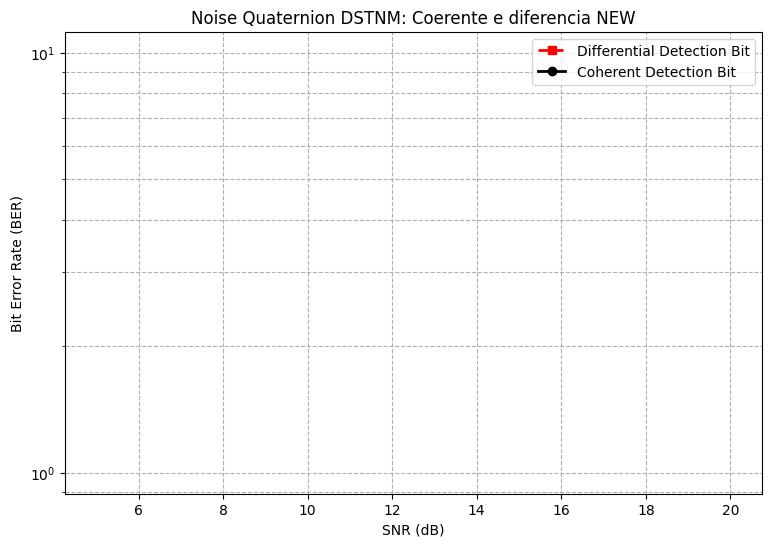

'\n\n\n'

In [87]:
# --- Execução e Plotagem  DSTNM  ---

snr_range = np.arange(5, 21, 2.5)

ser_diff, ser_coh, ber_diff, ber_coh = run_simulation_dstnm(snr_range, num_blocks=10000) # 10k=ruim / 100k=ok / 500k=bom  / 1M+=artigo
                                                                                          #            3mi                    30min

plt.figure(figsize=(9,6))

#plt.semilogy(snr_range, ser_diff, 'r--s', linewidth=2, markersize=6, label='Differential Detection Simbolo')
#plt.semilogy(snr_range, ser_coh, 'b--o', linewidth=2, markersize=6, label='Coherent Detection Simbolo')
plt.semilogy(snr_range, ber_diff, 'r--s', linewidth=2, markersize=6, label='Differential Detection Bit')
plt.semilogy(snr_range, ber_coh, 'k-o', linewidth=2, markersize=6, label='Coherent Detection Bit')

plt.grid(True, which="both", linestyle='--')
plt.xlabel('SNR (dB)')
plt.ylabel('Bit Error Rate (BER)')
plt.title('Noise Quaternion DSTNM: Coerente e diferencia NEW')
#plt.ylim(1e-4, 1e-0)
#plt.xticks(np.arange(5, 21, 2.5))   # de 50 até 400, de 50 em 50
#plt.xlim(5, 20)
plt.legend()

plt.show()
'''


'''

In [78]:
print(snr_range, ber_coh)   # SIMBOLO E BIT
print(snr_range, ber_diff)

[ 5.   7.5 10.  12.5 15.  17.5 20. ] [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
[ 5.   7.5 10.  12.5 15.  17.5 20. ] [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]


In [32]:
# CALCULO DA:  DISTANCIA DO PRODUTO
########## resumo
# Delta = diferença entre dois codigos
# zelta = multiplicação conjugado de cada delta
# dp(i,j) = det(zelta) = det(delta)^2   (PARA MATRIZES QUADRADAS)
##########
# Se dois codewords têm: det(Δ) ≈ 0
# significa: diferença quase rank-1.  perde diversidade.  pior BER

# Se têm: det(Δ) grande
# significa: boa separação espacial-temporal. diversidade total. melhor BER

# Sugestão de melhoria : m otimizador automático em Python que ajusta seu ruído base Z para maximizar:





import numpy as np
from itertools import combinations

def product_distance(A, B):
    Delta = A - B
    return abs(np.linalg.det(Delta))**2

def codebook_product_distance(codebook):
    vals = []

    for i, j in combinations(range(len(codebook)), 2):
        dp = product_distance(codebook[i], codebook[j])  # calcula dp final matriz quadrada!
        vals.append((i, j, dp))

    dmin = min(v[2] for v in vals)
    return dmin, vals

# uso
print("noise_codebook da vez: ", noise_codebook)
dmin, table = codebook_product_distance(noise_codebook)

print("Distância mínima de produto =", dmin)
print("Veja que a distancia mínima que define o codigo")
print("")
print("Veja que é uma combinação de cada codigo com todos - codebook de 8 = ")
print("C_(8,2)  = 8! / (2! 6!)  = 8*7*6! /2*6!  = 4*7 = 28 ")
print("")

for i, j, dp in table:
    print(f"Par ({i},{j}) -> {dp:.6f}")

noise_codebook da vez:  [array([[1.+0.j, 0.+0.j],
       [0.+0.j, 1.+0.j]]), array([[-1.-0.j, -0.-0.j],
       [-0.-0.j, -1.-0.j]]), array([[ 0.+1.j,  0.+0.j],
       [ 0.+0.j, -0.-1.j]]), array([[-0.-1.j, -0.-0.j],
       [-0.-0.j,  0.+1.j]]), array([[ 0.+0.j, -1.+0.j],
       [ 1.+0.j,  0.+0.j]]), array([[-0.-0.j,  1.-0.j],
       [-1.-0.j, -0.-0.j]]), array([[0.+0.j, 0.-1.j],
       [0.-1.j, 0.+0.j]]), array([[-0.-0.j, -0.+1.j],
       [-0.+1.j, -0.-0.j]])]
Distância mínima de produto = 3.9999999999999982
Veja que a distancia mínima que define o codigo

Veja que é uma combinação de cada codigo com todos - codebook de 8 = 
C_(8,2)  = 8! / (2! 6!)  = 8*7*6! /2*6!  = 4*7 = 28 

Par (0,1) -> 16.000000
Par (0,2) -> 4.000000
Par (0,3) -> 4.000000
Par (0,4) -> 4.000000
Par (0,5) -> 4.000000
Par (0,6) -> 4.000000
Par (0,7) -> 4.000000
Par (1,2) -> 4.000000
Par (1,3) -> 4.000000
Par (1,4) -> 4.000000
Par (1,5) -> 4.000000
Par (1,6) -> 4.000000
Par (1,7) -> 4.000000
Par (2,3) -> 16.000000
Par